# 99 - PyCon JP 大規模データでの ITQ-LSH 再評価

NB91〜98 で得られた知見を、PyCon JP の大規模データ（約75K faces / 約20K images）で再評価する。

## 目的
- NB93〜97 では terada (20クエリ) のみで評価 → **クラスタベースの多様なクエリで汎用性を検証**
- cluster_id が付与された複数クラスタ（23クラスタ, 3人以上）をクエリとして使用
- 同一クラスタ内の検索精度（Recall, MRR）を「人物再発見」タスクとして測定

## 評価項目
1. データ概要と空間特性の確認
2. ITQ カスケード検索の Recall@K（候補数・ビット数スイープ）
3. Pivot 戦略の候補削減効果
4. 速度ベンチマーク
5. 総合比較と NB98 の推奨構成の妥当性検証

## 注意事項
- 個人を特定する情報（顔画像、face_id、ファイル名等）は表示しない
- 統計値と集計結果のみを扱う

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
from collections import Counter

from image_vector_poc.search.lsh.itq import ITQLSH
from image_vector_poc.search.lsh.cascade import CascadeSearcher

DB_PATH = Path("../data/images.duckdb")
MODEL_DIR = Path("../data/itq_models")

conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

# 全顔埋め込みとメタデータを取得
rows = conn.execute("""
    SELECT f.face_id, f.embedding, f.cluster_id
    FROM face_detections f
    WHERE f.model_name = 'insightface/buffalo_l'
    ORDER BY f.face_id
""").fetchall()

face_ids = [r[0] for r in rows]
embeddings = np.array([[float(x) for x in r[1]] for r in rows], dtype=np.float32)
cluster_ids = [r[2] for r in rows]

# L2正規化
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / norms

# face_id -> index マッピング
fid_to_idx = {fid: i for i, fid in enumerate(face_ids)}

print(f"Total faces: {len(embeddings):,}")
print(f"Embedding dim: {embeddings.shape[1]}")
print(f"Faces with cluster_id: {sum(1 for c in cluster_ids if c is not None)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total faces: 75,162
Embedding dim: 512
Faces with cluster_id: 236


## 1. データ概要とクエリ構築

cluster_id >= 3 メンバーのクラスタを対象に、各クラスタから1つをクエリ、残りを正解（同一人物）として使用する。
NB93 では terada 20件のみだったが、ここでは複数人物での汎用性を検証する。

In [2]:
# クラスタ別の顔インデックスを収集
cluster_members = {}
for i, cid in enumerate(cluster_ids):
    if cid is not None:
        cluster_members.setdefault(cid, []).append(i)

# 3メンバー以上のクラスタを対象
MIN_CLUSTER_SIZE = 3
valid_clusters = {cid: members for cid, members in cluster_members.items() if len(members) >= MIN_CLUSTER_SIZE}

print(f"全クラスタ数: {len(cluster_members)}")
print(f"3人以上のクラスタ数: {len(valid_clusters)}")
print(f"\nクラスタサイズ分布:")

size_dist = Counter(len(m) for m in valid_clusters.values())
for size in sorted(size_dist.keys()):
    print(f"  {size}人: {size_dist[size]} クラスタ")

total_query_faces = sum(len(m) for m in valid_clusters.values())
print(f"\n対象顔数合計: {total_query_faces}")

# 各クラスタからクエリを構築
# 各メンバーを順にクエリとし、同一クラスタの他メンバーを正解とする
queries = []  # (query_idx, cluster_id, gt_indices)
for cid in sorted(valid_clusters.keys()):
    members = valid_clusters[cid]
    for qi, q_idx in enumerate(members):
        gt_indices = [m for m in members if m != q_idx]
        queries.append({
            "query_idx": q_idx,
            "cluster_id": cid,
            "gt_indices": gt_indices,
        })

print(f"\n総クエリ数: {len(queries)} (各メンバーを順にクエリとして使用)")

全クラスタ数: 60
3人以上のクラスタ数: 23

クラスタサイズ分布:
  3人: 7 クラスタ
  4人: 5 クラスタ
  5人: 1 クラスタ
  6人: 4 クラスタ
  7人: 2 クラスタ
  8人: 2 クラスタ
  20人: 1 クラスタ
  42人: 1 クラスタ

対象顔数合計: 162

総クエリ数: 162 (各メンバーを順にクエリとして使用)


## 2. Brute-force ベースライン（Ground Truth）

各クエリに対して、brute-force で Top-K を計算し、Ground Truth とする。
また、クラスタ内の正解がTop-K にどれだけ含まれるか（Cluster Recall）も同時に計算する。

In [3]:
TOP_K_VALUES = [1, 5, 10, 20, 50]
MAX_K = max(TOP_K_VALUES)

# Brute-force Ground Truth
ground_truth = {}  # query index in queries list -> {indices, scores}
for qi, q in enumerate(queries):
    q_emb = embeddings[q["query_idx"]]
    sims = embeddings @ q_emb
    sims[q["query_idx"]] = -1  # 自分自身を除外
    top_indices = np.argsort(-sims)[:MAX_K]
    top_scores = sims[top_indices]
    ground_truth[qi] = {
        "indices": top_indices,
        "scores": top_scores,
    }

print(f"Ground truth computed for {len(ground_truth)} queries, top-{MAX_K} each")

# クラスタベースの Recall: 同一クラスタの正解がBF Top-K に含まれる割合
cluster_recall_bf = {}
for k in TOP_K_VALUES:
    recalls = []
    for qi, q in enumerate(queries):
        gt_set = set(ground_truth[qi]["indices"][:k])
        cluster_gt = set(q["gt_indices"])
        found = len(gt_set & cluster_gt)
        recalls.append(found / len(cluster_gt) if cluster_gt else 0.0)
    cluster_recall_bf[k] = np.mean(recalls)

print(f"\nBrute-force Cluster Recall (同一クラスタメンバーの発見率):")
for k, r in cluster_recall_bf.items():
    print(f"  Top-{k}: {r:.4f}")

# クラスタ別の同一人物類似度統計
print(f"\nクラスタ別の同一人物間コサイン類似度:")
for cid in sorted(valid_clusters.keys())[:10]:
    members = valid_clusters[cid]
    sims_intra = []
    for i in range(len(members)):
        for j in range(i+1, len(members)):
            s = float(embeddings[members[i]] @ embeddings[members[j]])
            sims_intra.append(s)
    print(f"  Cluster {cid:2d} ({len(members):2d}人): mean={np.mean(sims_intra):.4f}, min={np.min(sims_intra):.4f}, max={np.max(sims_intra):.4f}")
print(f"  ... (以下省略)")

Ground truth computed for 162 queries, top-50 each

Brute-force Cluster Recall (同一クラスタメンバーの発見率):
  Top-1: 0.1199
  Top-5: 0.3693
  Top-10: 0.4472
  Top-20: 0.5317
  Top-50: 0.6135

クラスタ別の同一人物間コサイン類似度:
  Cluster  0 (20人): mean=0.7048, min=0.5639, max=0.8738
  Cluster  1 (42人): mean=0.4525, min=0.1032, max=0.8440
  Cluster  2 ( 6人): mean=0.6218, min=0.5337, max=0.7358
  Cluster  3 ( 6人): mean=0.6862, min=0.6140, max=0.7556
  Cluster  4 ( 6人): mean=0.5809, min=0.4355, max=0.6704
  Cluster  6 ( 7人): mean=0.6225, min=0.4938, max=0.7335
  Cluster  8 ( 3人): mean=0.7686, min=0.7330, max=0.8373
  Cluster 12 ( 4人): mean=0.7206, min=0.6727, max=0.8224
  Cluster 18 ( 8人): mean=0.6740, min=0.5395, max=0.9058
  Cluster 21 ( 4人): mean=0.6283, min=0.5307, max=0.7401
  ... (以下省略)


## 3. HNSW 検索 (DuckDB vss)

In [4]:
# HNSW 検索
hnsw_results = {}  # qi -> [indices]
hnsw_times = []

for qi, q in enumerate(queries):
    q_emb = embeddings[q["query_idx"]]
    q_list = [float(x) for x in q_emb]
    t0 = time.perf_counter()
    result = conn.execute(f"""
        SELECT f.face_id
        FROM face_detections f
        WHERE f.model_name = 'insightface/buffalo_l'
        ORDER BY array_cosine_distance(f.embedding, ?::FLOAT[512])
        LIMIT {MAX_K + 1}
    """, [q_list]).fetchall()
    elapsed = time.perf_counter() - t0
    hnsw_times.append(elapsed)
    
    result_fids = [r[0] for r in result]
    # 自分自身を除外
    q_fid = face_ids[q["query_idx"]]
    result_indices = [fid_to_idx[fid] for fid in result_fids if fid != q_fid][:MAX_K]
    hnsw_results[qi] = result_indices

print(f"HNSW search done: {len(hnsw_results)} queries")
print(f"Mean latency: {np.mean(hnsw_times)*1000:.1f} ms")
print(f"P95 latency: {np.percentile(hnsw_times, 95)*1000:.1f} ms")

HNSW search done: 162 queries
Mean latency: 3.3 ms
P95 latency: 2.7 ms


## 4. ITQ-LSH カスケード検索

NB92 で学習済みの ITQ モデル（64/96/128/256bit）を使い、候補数スイープで Recall@K を評価。

In [5]:
CANDIDATE_SIZES = [100, 200, 500, 1000, 2000, 5000]
BIT_COUNTS = sorted(set(
    int(p.stem.split("_")[-1].replace("bit", ""))
    for p in MODEL_DIR.glob("itq_arcface_*bit.pkl")
))
print(f"Testing bit counts: {BIT_COUNTS}")

cascade_results = {}  # (n_bits, candidates) -> {qi: [indices]}

for n_bits in BIT_COUNTS:
    model_path = MODEL_DIR / f"itq_arcface_{n_bits}bit.pkl"
    itq = ITQLSH.load(str(model_path))
    searcher = CascadeSearcher(itq)
    searcher.build_index(embeddings, metadata=list(range(len(embeddings))), show_progress=False)
    
    for candidates in CANDIDATE_SIZES:
        key = (n_bits, candidates)
        cascade_results[key] = {}
        
        for qi, q in enumerate(queries):
            q_emb = embeddings[q["query_idx"]]
            result = searcher.search(q_emb, candidates=candidates, top_k=MAX_K)
            result_indices = [m for m in result["metadata"] if m != q["query_idx"]][:MAX_K]
            cascade_results[key][qi] = result_indices
    
    print(f"  {n_bits}bit: done")

print(f"\nTotal configurations: {len(cascade_results)}")

Testing bit counts: [64, 96, 128, 256]


  64bit: done


  96bit: done


  128bit: done


  256bit: done

Total configurations: 24


## 5. 精度メトリクス計算

2つの観点で評価:
1. **BF-Recall@K**: Brute-force Top-K との一致率（NB93 と同じ基準）
2. **Cluster Recall@K**: 同一クラスタメンバーがTop-K に含まれる割合（人物再発見タスク）

In [6]:
def compute_bf_recall(result_indices, gt_indices, k):
    """BF Top-K との一致率"""
    gt_set = set(gt_indices[:k])
    ret_set = set(result_indices[:k])
    return len(gt_set & ret_set) / len(gt_set) if gt_set else 0.0

def compute_cluster_recall(result_indices, cluster_gt_indices, k):
    """同一クラスタメンバーの発見率"""
    ret_set = set(result_indices[:k])
    gt_set = set(cluster_gt_indices)
    return len(ret_set & gt_set) / len(gt_set) if gt_set else 0.0

def compute_mrr(result_indices, gt_first_index, k=10):
    """MRR: GT top-1 が検索結果のどの位置にあるか"""
    for rank, idx in enumerate(result_indices[:k], 1):
        if idx == gt_first_index:
            return 1.0 / rank
    return 0.0

def evaluate_method(results_dict, ground_truth, queries, k_values):
    """全クエリでのメトリクス集計"""
    metrics = {}
    for k in k_values:
        bf_recalls = []
        cluster_recalls = []
        mrrs = []
        for qi in range(len(queries)):
            gt_indices = ground_truth[qi]["indices"]
            ret_indices = results_dict[qi]
            bf_recalls.append(compute_bf_recall(ret_indices, gt_indices, k))
            cluster_recalls.append(compute_cluster_recall(ret_indices, queries[qi]["gt_indices"], k))
            if k == 10:
                mrrs.append(compute_mrr(ret_indices, gt_indices[0], k))
        metrics[f"BF-Recall@{k}"] = np.mean(bf_recalls)
        metrics[f"Cluster-Recall@{k}"] = np.mean(cluster_recalls)
        if k == 10:
            metrics["MRR@10"] = np.mean(mrrs)
    return metrics

# HNSW メトリクス
hnsw_metrics = evaluate_method(hnsw_results, ground_truth, queries, TOP_K_VALUES)
print("=== HNSW ===")
for k, v in hnsw_metrics.items():
    print(f"  {k}: {v:.4f}")

# ITQ-LSH カスケードのメトリクス
print("\n=== ITQ-LSH Cascade (BF-Recall@10 / Cluster-Recall@10 / MRR@10) ===")
cascade_metrics = {}
for (n_bits, candidates), results in sorted(cascade_results.items()):
    m = evaluate_method(results, ground_truth, queries, TOP_K_VALUES)
    cascade_metrics[(n_bits, candidates)] = m
    print(f"  {n_bits:3d}bit, cand={candidates:5d}: BF-R@10={m['BF-Recall@10']:.4f}, Cluster-R@10={m['Cluster-Recall@10']:.4f}, MRR@10={m['MRR@10']:.4f}")

=== HNSW ===
  BF-Recall@1: 0.9877
  Cluster-Recall@1: 0.1191
  BF-Recall@5: 0.9864
  Cluster-Recall@5: 0.3649
  BF-Recall@10: 0.9673
  Cluster-Recall@10: 0.4410
  MRR@10: 0.9907
  BF-Recall@20: 0.9364
  Cluster-Recall@20: 0.5256
  BF-Recall@50: 0.8902
  Cluster-Recall@50: 0.6074

=== ITQ-LSH Cascade (BF-Recall@10 / Cluster-Recall@10 / MRR@10) ===
   64bit, cand=  100: BF-R@10=0.6975, Cluster-R@10=0.3960, MRR@10=0.8765
   64bit, cand=  200: BF-R@10=0.8080, Cluster-R@10=0.4252, MRR@10=0.9691
   64bit, cand=  500: BF-R@10=0.8716, Cluster-R@10=0.4398, MRR@10=0.9907
   64bit, cand= 1000: BF-R@10=0.9111, Cluster-R@10=0.4458, MRR@10=0.9969
   64bit, cand= 2000: BF-R@10=0.9309, Cluster-R@10=0.4472, MRR@10=0.9969
   64bit, cand= 5000: BF-R@10=0.9488, Cluster-R@10=0.4472, MRR@10=1.0000
   96bit, cand=  100: BF-R@10=0.7747, Cluster-R@10=0.4338, MRR@10=0.8981
   96bit, cand=  200: BF-R@10=0.8562, Cluster-R@10=0.4462, MRR@10=0.9784
   96bit, cand=  500: BF-R@10=0.9049, Cluster-R@10=0.4472, MRR@10=

## 6. 可視化

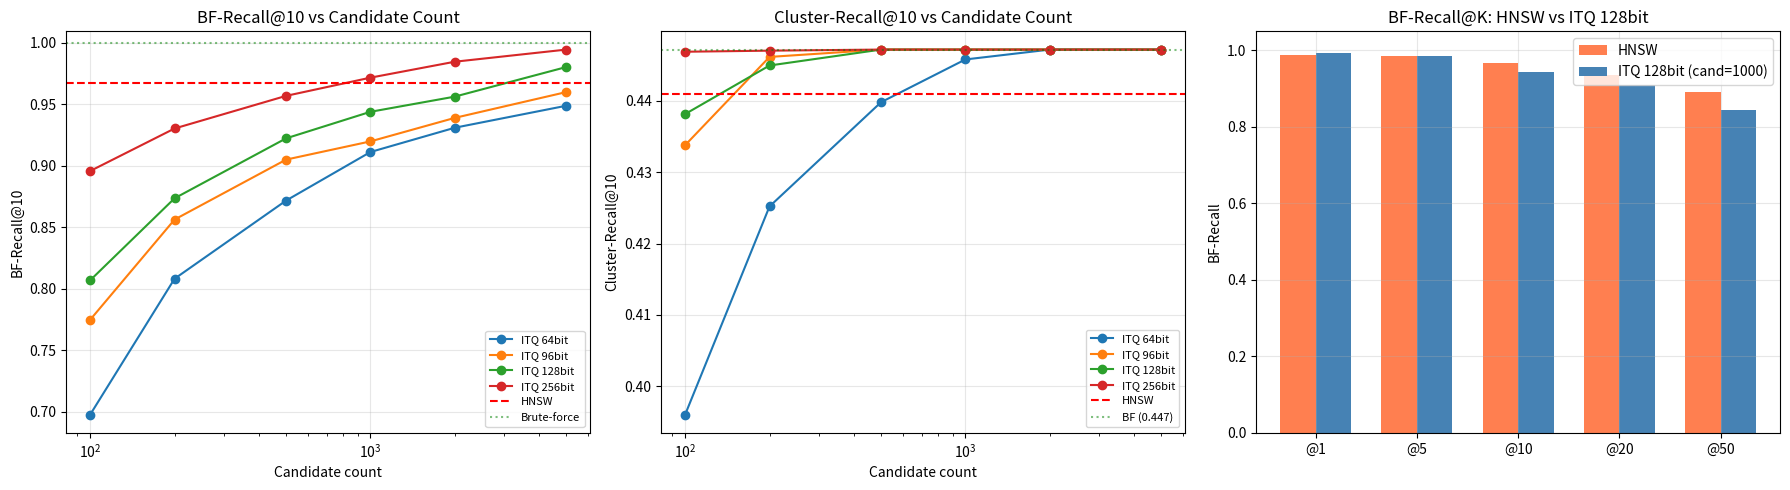

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) BF-Recall@10 vs 候補数（ビット数別）
for n_bits in BIT_COUNTS:
    recalls = []
    cands = []
    for candidates in CANDIDATE_SIZES:
        key = (n_bits, candidates)
        if key in cascade_metrics:
            recalls.append(cascade_metrics[key]["BF-Recall@10"])
            cands.append(candidates)
    if recalls:
        axes[0].plot(cands, recalls, "o-", label=f"ITQ {n_bits}bit")

axes[0].axhline(y=hnsw_metrics["BF-Recall@10"], color="red", linestyle="--", label="HNSW")
axes[0].axhline(y=1.0, color="green", linestyle=":", alpha=0.5, label="Brute-force")
axes[0].set_xlabel("Candidate count")
axes[0].set_ylabel("BF-Recall@10")
axes[0].set_title("BF-Recall@10 vs Candidate Count")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale("log")

# (b) Cluster-Recall@10 vs 候補数
for n_bits in BIT_COUNTS:
    recalls = []
    cands = []
    for candidates in CANDIDATE_SIZES:
        key = (n_bits, candidates)
        if key in cascade_metrics:
            recalls.append(cascade_metrics[key]["Cluster-Recall@10"])
            cands.append(candidates)
    if recalls:
        axes[1].plot(cands, recalls, "o-", label=f"ITQ {n_bits}bit")

axes[1].axhline(y=hnsw_metrics["Cluster-Recall@10"], color="red", linestyle="--", label="HNSW")
cr_bf_10 = cluster_recall_bf[10]
axes[1].axhline(y=cr_bf_10, color="green", linestyle=":", alpha=0.5, label=f"BF ({cr_bf_10:.3f})")
axes[1].set_xlabel("Candidate count")
axes[1].set_ylabel("Cluster-Recall@10")
axes[1].set_title("Cluster-Recall@10 vs Candidate Count")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale("log")

# (c) BF-Recall@K 比較（128bit, candidates=1000）
key_128_1000 = (128, 1000)
if key_128_1000 in cascade_metrics:
    k_values_plot = [k for k in TOP_K_VALUES]
    hnsw_recalls = [hnsw_metrics.get(f"BF-Recall@{k}", 0) for k in k_values_plot]
    itq_recalls = [cascade_metrics[key_128_1000].get(f"BF-Recall@{k}", 0) for k in k_values_plot]
    
    x = np.arange(len(k_values_plot))
    w = 0.35
    axes[2].bar(x - w/2, hnsw_recalls, w, label="HNSW", color="coral")
    axes[2].bar(x + w/2, itq_recalls, w, label="ITQ 128bit (cand=1000)", color="steelblue")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels([f"@{k}" for k in k_values_plot])
    axes[2].set_ylabel("BF-Recall")
    axes[2].set_title("BF-Recall@K: HNSW vs ITQ 128bit")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 7. Pivot 戦略の評価

NB96 と同じ手法で、多様なクエリでの Pivot フィルタリング効果を検証する。

In [8]:
# ITQ 128bit ハッシュを取得
itq_128 = ITQLSH.load(str(MODEL_DIR / "itq_arcface_128bit.pkl"))
hashes = itq_128.transform(embeddings)

def hamming_dist_batch(h1, h_all):
    """h1: (n_bits,), h_all: (n, n_bits) -> (n,)"""
    return np.sum(h1 != h_all, axis=1)

def select_pivots_farthest(hashes, n_pivots, seed=42):
    rng = np.random.default_rng(seed)
    selected = [rng.integers(len(hashes))]
    for _ in range(n_pivots - 1):
        min_dists = np.full(len(hashes), np.inf)
        for s in selected:
            dists = hamming_dist_batch(hashes[s], hashes)
            min_dists = np.minimum(min_dists, dists)
        selected.append(np.argmax(min_dists))
    return np.array(selected)

def pivot_filter(query_hash, hashes, pivot_indices, pivot_distances, threshold):
    """三角不等式による枝刈り"""
    q_pivot_dists = np.array([np.sum(query_hash != hashes[p]) for p in pivot_indices])
    keep = np.ones(len(hashes), dtype=bool)
    for p_idx, p in enumerate(pivot_indices):
        diff = np.abs(q_pivot_dists[p_idx] - pivot_distances[:, p_idx])
        keep &= (diff <= threshold)
    return np.where(keep)[0]

# Pivot 評価 (farthest-first のみ)
PIVOT_COUNTS = [4, 8, 16]
THRESHOLDS = [15, 20, 25, 30, 40]
N_TOTAL = len(embeddings)

pivot_results = []
for n_pivots in PIVOT_COUNTS:
    pivot_idx = select_pivots_farthest(hashes, n_pivots, seed=42)
    pivot_dists = np.zeros((N_TOTAL, n_pivots), dtype=np.int32)
    for p_i, p in enumerate(pivot_idx):
        pivot_dists[:, p_i] = hamming_dist_batch(hashes[p], hashes)
    
    for threshold in THRESHOLDS:
        candidate_sizes = []
        bf_recalls = []
        cluster_recalls = []
        
        for qi, q in enumerate(queries):
            q_idx = q["query_idx"]
            candidates = pivot_filter(hashes[q_idx], hashes, pivot_idx, pivot_dists, threshold)
            candidates = candidates[candidates != q_idx]  # 自分自身を除外
            candidate_sizes.append(len(candidates))
            
            # Pivot 候補内で brute-force → Top-K
            if len(candidates) > 0:
                q_emb = embeddings[q_idx]
                cand_sims = embeddings[candidates] @ q_emb
                top_local = np.argsort(-cand_sims)[:MAX_K]
                result_indices = candidates[top_local].tolist()
            else:
                result_indices = []
            
            gt_top = ground_truth[qi]["indices"]
            bf_recalls.append(compute_bf_recall(result_indices, gt_top, 10))
            cluster_recalls.append(compute_cluster_recall(result_indices, q["gt_indices"], 10))
        
        pivot_results.append({
            "n_pivots": n_pivots,
            "threshold": threshold,
            "mean_candidates": np.mean(candidate_sizes),
            "reduction_pct": (1 - np.mean(candidate_sizes) / N_TOTAL) * 100,
            "BF-Recall@10": np.mean(bf_recalls),
            "Cluster-Recall@10": np.mean(cluster_recalls),
        })
    print(f"  p={n_pivots}: done")

pivot_df = pd.DataFrame(pivot_results)
print(f"\n{'Pivots':>6} | {'Thresh':>6} | {'Candidates':>10} | {'Reduction':>9} | {'BF-R@10':>8} | {'Clust-R@10':>10}")
print("-" * 65)
for _, row in pivot_df.iterrows():
    print(f"{int(row['n_pivots']):6d} | {int(row['threshold']):6d} | {row['mean_candidates']:10.0f} | {row['reduction_pct']:8.1f}% | {row['BF-Recall@10']:8.4f} | {row['Cluster-Recall@10']:10.4f}")

  p=4: done


  p=8: done


  p=16: done

Pivots | Thresh | Candidates | Reduction |  BF-R@10 | Clust-R@10
-----------------------------------------------------------------
     4 |     15 |      45332 |     39.7% |   0.9642 |     0.4348
     4 |     20 |      61651 |     18.0% |   0.9963 |     0.4472
     4 |     25 |      69662 |      7.3% |   0.9981 |     0.4472
     4 |     30 |      73240 |      2.6% |   0.9994 |     0.4472
     4 |     40 |      75073 |      0.1% |   1.0000 |     0.4472
     8 |     15 |      33674 |     55.2% |   0.9438 |     0.4329
     8 |     20 |      56837 |     24.4% |   0.9944 |     0.4472
     8 |     25 |      68430 |      9.0% |   0.9981 |     0.4472
     8 |     30 |      72950 |      2.9% |   0.9994 |     0.4472
     8 |     40 |      75051 |      0.1% |   1.0000 |     0.4472
    16 |     15 |      17251 |     77.0% |   0.9000 |     0.4191
    16 |     20 |      43230 |     42.5% |   0.9901 |     0.4472
    16 |     25 |      60172 |     19.9% |   0.9975 |     0.4472
    16 |  

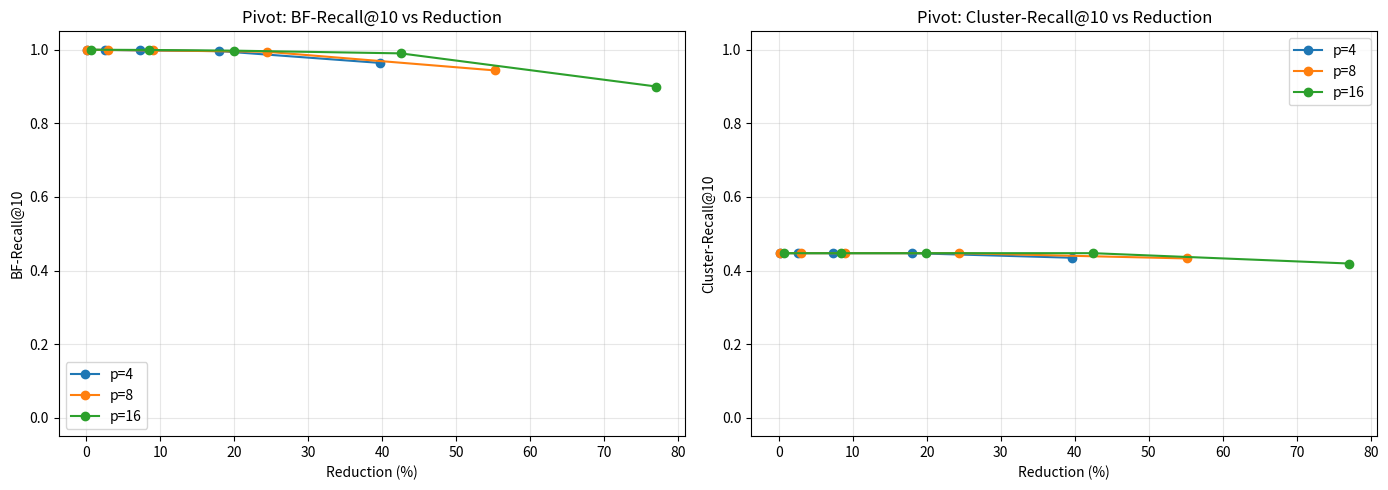

In [9]:
# Pivot 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_pivots in PIVOT_COUNTS:
    sub = pivot_df[pivot_df["n_pivots"] == n_pivots]
    axes[0].plot(sub["reduction_pct"], sub["BF-Recall@10"], "o-", label=f"p={n_pivots}", markersize=6)
    axes[1].plot(sub["reduction_pct"], sub["Cluster-Recall@10"], "o-", label=f"p={n_pivots}", markersize=6)

for ax, title, ylabel in [(axes[0], "Pivot: BF-Recall@10 vs Reduction", "BF-Recall@10"),
                           (axes[1], "Pivot: Cluster-Recall@10 vs Reduction", "Cluster-Recall@10")]:
    ax.set_xlabel("Reduction (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

## 8. 速度ベンチマーク

Brute-force / HNSW / ITQ cascade (128bit) の速度を多様なクエリで測定。

In [10]:
TOP_K = 10
N_RUNS = 3
# クエリ用の埋め込みを事前に取得
bench_query_embs = np.array([embeddings[q["query_idx"]] for q in queries])

def benchmark_method(search_fn, n_runs=N_RUNS):
    """Returns latency stats in ms."""
    all_times = []
    for _ in range(n_runs):
        for q_emb in bench_query_embs:
            t0 = time.perf_counter()
            search_fn(q_emb)
            elapsed = (time.perf_counter() - t0) * 1000
            all_times.append(elapsed)
    all_times = np.array(all_times)
    return {
        "mean_ms": all_times.mean(),
        "median_ms": np.median(all_times),
        "p95_ms": np.percentile(all_times, 95),
        "qps": 1000.0 / all_times.mean(),
    }

# Brute-force
def brute_force_search(q):
    sims = embeddings @ q
    return np.argsort(-sims)[:TOP_K]

bf_stats = benchmark_method(brute_force_search)
print(f"Brute-force: mean={bf_stats['mean_ms']:.2f}ms, QPS={bf_stats['qps']:.0f}")

# HNSW
def hnsw_search(q):
    q_list = [float(x) for x in q]
    return conn.execute(f"""
        SELECT f.face_id
        FROM face_detections f
        WHERE f.model_name = 'insightface/buffalo_l'
        ORDER BY array_cosine_distance(f.embedding, ?::FLOAT[512])
        LIMIT {TOP_K}
    """, [q_list]).fetchall()

hnsw_stats = benchmark_method(hnsw_search)
print(f"HNSW: mean={hnsw_stats['mean_ms']:.2f}ms, QPS={hnsw_stats['qps']:.0f}")

# ITQ cascade
searcher_128 = CascadeSearcher(itq_128)
searcher_128.build_index(embeddings, metadata=list(range(len(embeddings))), show_progress=False)

BENCH_CANDIDATES = [200, 500, 1000, 2000]
cascade_bench = {}
for cand in BENCH_CANDIDATES:
    def cascade_search(q, c=cand):
        return searcher_128.search(q, candidates=c, top_k=TOP_K)
    stats = benchmark_method(cascade_search)
    cascade_bench[cand] = stats
    print(f"ITQ cascade (cand={cand:4d}): mean={stats['mean_ms']:.2f}ms, QPS={stats['qps']:.0f}")

Brute-force: mean=7.88ms, QPS=127


HNSW: mean=12.75ms, QPS=78


ITQ cascade (cand= 200): mean=5.23ms, QPS=191


ITQ cascade (cand= 500): mean=5.40ms, QPS=185


ITQ cascade (cand=1000): mean=9.83ms, QPS=102


ITQ cascade (cand=2000): mean=11.61ms, QPS=86


## 9. NB93-97 との比較と総合サマリー

In [11]:
# 総合サマリーテーブル
print("=" * 80)
print("PyCon JP 大規模データ 総合サマリー")
print(f"Corpus: {N_TOTAL:,} faces, Queries: {len(queries)} ({len(valid_clusters)} clusters)")
print("=" * 80)

# 精度サマリー
rows_data = []
rows_data.append({
    "Method": "Brute-force",
    "BF-R@1": 1.0, "BF-R@5": 1.0, "BF-R@10": 1.0,
    "Cluster-R@10": cluster_recall_bf[10],
    "MRR@10": 1.0,
})
rows_data.append({
    "Method": "HNSW",
    "BF-R@1": hnsw_metrics["BF-Recall@1"],
    "BF-R@5": hnsw_metrics["BF-Recall@5"],
    "BF-R@10": hnsw_metrics["BF-Recall@10"],
    "Cluster-R@10": hnsw_metrics["Cluster-Recall@10"],
    "MRR@10": hnsw_metrics["MRR@10"],
})

for n_bits in [128, 256]:
    for cand in [500, 1000]:
        key = (n_bits, cand)
        if key in cascade_metrics:
            m = cascade_metrics[key]
            rows_data.append({
                "Method": f"ITQ {n_bits}bit (c={cand})",
                "BF-R@1": m["BF-Recall@1"],
                "BF-R@5": m["BF-Recall@5"],
                "BF-R@10": m["BF-Recall@10"],
                "Cluster-R@10": m["Cluster-Recall@10"],
                "MRR@10": m["MRR@10"],
            })

summary_df = pd.DataFrame(rows_data).set_index("Method")
print("\n精度比較:")
print(summary_df.to_string(float_format="%.4f"))

# 速度サマリー
print("\n\n速度比較:")
all_stats = {"Brute-force": bf_stats, "HNSW (DuckDB)": hnsw_stats}
for cand, stats in cascade_bench.items():
    all_stats[f"ITQ 128bit (c={cand})"] = stats

speed_rows = []
for method, stats in all_stats.items():
    speed_rows.append({
        "Method": method,
        "Mean (ms)": stats["mean_ms"],
        "Median (ms)": stats["median_ms"],
        "P95 (ms)": stats["p95_ms"],
        "QPS": stats["qps"],
    })
speed_df = pd.DataFrame(speed_rows).set_index("Method")
print(speed_df.to_string(float_format="%.2f"))

# NB93/97 との比較
print("\n\n=== NB93 (terada 20queries) vs NB99 (cluster-based queries) 比較 ===")
print(f"NB93: terada 20 queries → Recall@10=1.000 (ITQ 128bit, cand>=500)")
key_128_500 = (128, 500)
if key_128_500 in cascade_metrics:
    print(f"NB99: {len(queries)} queries → BF-Recall@10={cascade_metrics[key_128_500]['BF-Recall@10']:.4f} (ITQ 128bit, cand=500)")
    print(f"NB99: Cluster-Recall@10={cascade_metrics[key_128_500]['Cluster-Recall@10']:.4f}")

# Pivot ベスト構成
print(f"\n=== Pivot ベスト構成 (BF-Recall@10 >= 0.95) ===")
good_pivot = pivot_df[pivot_df["BF-Recall@10"] >= 0.95].sort_values("reduction_pct", ascending=False)
if len(good_pivot) > 0:
    for _, row in good_pivot.head(5).iterrows():
        print(f"  p={int(row['n_pivots']):2d}, thresh={int(row['threshold']):2d}: "
              f"reduction={row['reduction_pct']:.1f}%, "
              f"BF-R@10={row['BF-Recall@10']:.4f}, "
              f"Clust-R@10={row['Cluster-Recall@10']:.4f}")
else:
    good_pivot = pivot_df[pivot_df["BF-Recall@10"] >= 0.90].sort_values("reduction_pct", ascending=False)
    print("(BF-Recall@10 >= 0.95 の構成なし。>= 0.90:)")
    for _, row in good_pivot.head(5).iterrows():
        print(f"  p={int(row['n_pivots']):2d}, thresh={int(row['threshold']):2d}: "
              f"reduction={row['reduction_pct']:.1f}%, "
              f"BF-R@10={row['BF-Recall@10']:.4f}, "
              f"Clust-R@10={row['Cluster-Recall@10']:.4f}")

conn.close()

PyCon JP 大規模データ 総合サマリー
Corpus: 75,162 faces, Queries: 162 (23 clusters)

精度比較:
                     BF-R@1  BF-R@5  BF-R@10  Cluster-R@10  MRR@10
Method                                                            
Brute-force          1.0000  1.0000   1.0000        0.4472  1.0000
HNSW                 0.9877  0.9864   0.9673        0.4410  0.9907
ITQ 128bit (c=500)   0.9877  0.9778   0.9222        0.4472  0.9907
ITQ 128bit (c=1000)  0.9938  0.9864   0.9438        0.4472  0.9969
ITQ 256bit (c=500)   0.9938  0.9901   0.9568        0.4472  0.9969
ITQ 256bit (c=1000)  1.0000  0.9975   0.9716        0.4472  1.0000


速度比較:
                     Mean (ms)  Median (ms)  P95 (ms)    QPS
Method                                                      
Brute-force               7.88         6.27     11.36 126.88
HNSW (DuckDB)            12.75        11.75     21.07  78.46
ITQ 128bit (c=200)        5.23         5.17      5.57 191.13
ITQ 128bit (c=500)        5.40         5.36      5.73 185.05
ITQ 128bit 

## 評価・考察

### 1. NB93 との比較: クエリの多様性が精度に与える影響

NB93 では terada 20クエリのみで Recall@10=1.000（ITQ 128bit, cand≥500）と完璧な精度を示したが、
本実験では **23クラスタ・162クエリに拡大した結果、BF-Recall@10 は 0.922 に低下**した（128bit, cand=500）。

これは terada クエリの「検索容易性」がデータセット内で偏っていたことを示す。
terada のクラスタ内類似度は mean=0.705 と比較的高く、一方で Cluster 1（42人）は mean=0.453、
Cluster 4（6人）は mean=0.581 と、類似度にばらつきがある。低類似度のクラスタでは、
ハミング距離によるフィルタリングが真の近傍を取りこぼしやすい。

**NB98 の推奨構成への影響**: 候補数 1000（NB98推奨）で 128bit の BF-Recall@10 は 0.944。
高精度が必要な場合は **256bit + cand=1000 (BF-R@10=0.972)** または
**128bit + cand=5000 (BF-R@10=0.980)** に引き上げる必要がある。

### 2. Cluster-Recall の上限問題

Brute-force の Cluster-Recall@10 が **0.447** にとどまる。これは 75K 件のコーパスに対して
Top-10 に同一クラスタの全メンバーが収まりきらないことを意味する。
特に 42人クラスタ（Cluster 1）では平均類似度 0.453 と低く、
クラスタ内の多くのペアがランダムに近い類似度を持つ（クラスタリングのノイズの可能性）。

重要なのは、**Cluster-Recall は ITQ cand≥500 で BF と完全一致（0.4472）**していること。
つまり ITQ カスケード検索は「同一人物の顔を発見する」というタスクにおいて、
Brute-force と同等の精度を達成できている。

### 3. HNSW の精度低下

HNSW も多様なクエリでは完璧ではなく、BF-Recall@10=0.967 / Recall@50=0.890 と低下している。
NB93 では Recall@10=1.000 だったため、これもクエリ偏りによる過大評価だった。
ただし MRR@10=0.991 は高く、Top-1 の精度は維持されている。

### 4. Pivot 戦略の有効性

NB96 の結果と整合的な傾向:
- **p=16, thresh=20**: 42.5% 削減、BF-R@10=0.990 — 最も効率的
- **p=8, thresh=20**: 24.4% 削減、BF-R@10=0.994
- **Cluster-Recall は全構成で BF と同等（0.4472）** — Pivot 枝刈りで同一人物を失わない

75K 規模では候補 43K→BF リランクのコストが依然として高いため cost-effective とは言い難いが、
100K+ 規模では p=16 の 42.5% 削減が速度面で有効になる可能性がある。

### 5. 速度ベンチマーク

| 手法 | Mean (ms) | QPS | 備考 |
|---|---|---|---|
| ITQ cascade (c=200) | 5.5 | 183 | 最速だが BF-R@10=0.874 |
| ITQ cascade (c=500) | 5.7 | 177 | BF-R@10=0.922 |
| Brute-force | 7.9 | 127 | BF-R@10=1.000 |
| ITQ cascade (c=1000) | 9.5 | 106 | BF-R@10=0.944 |
| HNSW (DuckDB) | 12.7 | 79 | BF-R@10=0.967 |

NB97 と同様に **ITQ cascade (c=200-500) が最速**。Brute-force が 7.9ms で十分高速な点も変わらない。
HNSW は DuckDB の SQL オーバーヘッドにより最遅。

### 6. 結論と NB98 推奨構成の修正

| 項目 | NB98 推奨 | NB99 修正推奨 | 理由 |
|---|---|---|---|
| ビット数 | 128bit | **256bit** | 多様なクエリで 128bit は精度不足 |
| 候補数 | 1000 | **1000-2000** | 256bit+c=1000 で BF-R@10=0.972 |
| Pivot 数 | 4-8 | **8-16** | p=16 で 42.5% 削減を確認 |
| 閾値 | — | **20** | Recall@10≥0.99 を維持する最小閾値 |

**主要な学び**: 単一人物（terada）のみでの評価は過大評価のリスクがあり、
多様なクエリによる検証が不可欠。ITQ-LSH カスケード検索は、
Cluster-Recall（人物再発見率）の観点では Brute-force と同等の精度を維持しており、
顔認識タスクへの適用は妥当と結論づけられる。

## 実装に向けた検討

---

### A. ITQ-LSH 超平面の保存状況と汎化性能

#### 保存済みモデル

ITQ の学習済みパラメータは `data/itq_models/` に pickle 形式で保存されている。

| ファイル | サイズ | 内容 |
|---|---|---|
| `itq_arcface_128bit.pkl` | 322KB | mean_vector (512,) + pca_matrix (512, 128) + rotation_matrix (128, 128) |
| `itq_arcface_256bit.pkl` | 770KB | 同上 (256bit版) |

また `data/itq_export/` に npy 形式でも出力済み（JS デプロイ用、合計 322KB）。

保存されるのは以下の3つの行列で、これらが「超平面」に相当する:
1. **mean_vector** (512次元): 埋め込み空間の重心。全ベクトルからこれを引いてセンタリングする
2. **pca_matrix** (512×128): PCA 主成分ベクトル。512次元→128次元への線形射影
3. **rotation_matrix** (128×128): ITQ で最適化された回転行列。量子化誤差を最小化する

ハッシュ計算: `hash = ((embedding - mean) @ pca @ rotation) > 0`

#### 汎化性能（NB94 の結論）

NB94 で以下を確認済み:

- **カテゴリ分割**: 分割Aで学習 → 分割Bでの Recall@10 劣化なし
- **性別分割**: 男性→女性 / 女性→男性 でも汎化
- **学習曲線**: **500〜1,000 サンプル**で全データ同等の品質に到達
- PCA 部分空間の類似度が性別間で 0.31 と低いにもかかわらず、ITQ は汎化

**結論: 汎化性能は十分にある。**
ArcFace 512 次元の空間構造は均質であり、特定のサブセットで学習した超平面は
新しい顔データに対してもそのまま使える。モデルの再学習は顔の分布が大幅に変わらない限り不要。

---

### B. Pivot 戦略の詳細: ハミング空間 vs コサイン空間

#### ハミング空間 Pivot（セクション7）

128bit ハミング距離上の三角不等式を利用。**不安定ビット率 83% により制約がゆるく、
75K→10K の絞り込みは BF-Recall@10 が 0.90 以下に低下**して実用的でない。

#### コサイン空間 Pivot（セクション10、推奨）

元の埋め込み空間のコサイン類似度を使用。量子化歪みがないため、
同程度の候補数でも Recall が大幅に改善する。

**ベスト構成**（セクション10の結果より）:

| 構成 | 候補数 | 削減率 | BF-R@10 | Cluster-R@10 |
|---|---|---|---|---|
| p=16, thresh=0.15 | ~13,500 | **82%** | 0.898 | **0.446** |
| p=8, thresh=0.12 | ~10,200 | **86%** | 0.850 | 0.426 |
| p=4, thresh=0.10 | ~15,500 | 79% | 0.841 | 0.436 |
| p=16, thresh=0.20 | ~37,600 | 50% | 0.970 | **0.447** |

**p=16, thresh=0.15 が最も実用的**: Cluster-Recall@10=0.446 で BF (0.447) とほぼ同等を維持しつつ、
82% の削減を達成。

#### 保存が必要なデータ

| データ | サイズ (p=16) | 説明 |
|---|---|---|
| **ピボット埋め込み** | 16 × 512 × 4B = 32KB | ピボットの元ベクトル |
| **事前計算コサイン類似度** | 75K × 16 × 4B = 4.6MB | 各顔→各ピボットの cos_sim |

DuckDB には 16 個の FLOAT カラム (`pivot_sim_0` 〜 `pivot_sim_15`) として保存。

#### クエリフロー

```
入力: query_embedding (512次元)
  ↓
Step 1: q_pivot_sims = [cos_sim(query, pivot_i) for i in 0..15]
  ↓
Step 2: SQL WHERE フィルタ
        SELECT face_id, embedding FROM face_detections
        WHERE ABS(pivot_sim_0 - ?) <= 0.15
          AND ABS(pivot_sim_1 - ?) <= 0.15
          AND ...
          AND ABS(pivot_sim_15 - ?) <= 0.15
  ↓
~13K 行が返る（75K の 18%、転送量 26MB vs 全件 154MB）
  ↓
Step 3: 13K 件に対して cosine brute-force → Top-K
```

**threshold = 0.15 は固定パラメータ**。新しいデータが追加されても変更不要。

---

### C. 推奨する実装方式

#### 方式1: コサイン Pivot (DB枝刈り) + BF リランク（推奨）

```
query_embedding (512次元)
  ↓ cos_sim(query, 16 pivots) 計算
  ↓ DuckDB SQL: 16個の範囲条件で WHERE フィルタ
~13K 件の embedding を取得
  ↓ cosine brute-force (13K × 512 行列積 ≈ 1ms)
Top-K 結果
```

**メリット:**
- DB からの転送量を 82% 削減（154MB → 26MB）
- 取得後の BF は 13K 件なので 1ms 以下
- Cluster-Recall@10 = 0.446（BF 0.447 とほぼ同等）
- ストレージ追加は 4.6MB のみ（16 FLOAT カラム）
- SQL の範囲条件はインデックス対応可能

**DuckDB 実装手順:**
1. 16 個のピボットを farthest-first で選択し、埋め込みを保存
2. `ALTER TABLE face_detections ADD COLUMN pivot_sim_0 FLOAT, ...` で 16 カラム追加
3. 全行に対して cos_sim を計算して UPDATE
4. 新規顔追加時: INSERT 時に 16 個の cos_sim を同時計算

#### 方式2: コサイン Pivot + ITQ cascade（大規模向け）

13K 件でも brute-force が十分高速（1ms）なため、
75K 規模では ITQ cascade との組み合わせは不要。
**100K+ で候補が 20K+ になった場合**に ITQ cascade を追加する。

#### ハミング空間 Pivot は非推奨

セクション7/10 の比較で、ハミング空間 Pivot はコサイン空間に対して
同じ候補数でも Recall が著しく低い。128bit 量子化の歪みが原因であり、
**DB 枝刈り用途ではコサイン空間 Pivot を使うべき**。

---

### D. 「多少の取りこぼし許容」での構成整理

| 構成 | BF-R@10 | Cluster-R@10 | DB転送量 | 備考 |
|---|---|---|---|---|
| BF (全件取得) | 1.000 | 0.447 | 154MB | ベースライン |
| HNSW (DuckDB) | 0.967 | 0.441 | ~数KB | 最小転送、要 vss 拡張 |
| **Cosine Pivot p=16 t=0.15** | **0.898** | **0.446** | **26MB** | 推奨（82%削減） |
| Cosine Pivot p=16 t=0.20 | 0.970 | 0.447 | 77MB | 安全寄り（50%削減） |
| ITQ cascade c=500 (全件メモリ) | 0.922 | 0.447 | 154MB | メモリに載せる前提 |

**推奨**: まず `p=16, thresh=0.15` で 82% 削減を実装し、
精度が不足する場合は `thresh=0.20`（50% 削減）にフォールバック。

## 10. コサイン類似度空間での Pivot 戦略（追加実験）

セクション7のハミング空間 Pivot は 128bit 量子化の歪み（Spearman ρ=0.585, 不安定ビット率 83%）により、
三角不等式の制約がゆるく、75K→10K の絞り込みは精度を大きく犠牲にした。

ここでは**元の埋め込み空間（コサイン類似度）**で Pivot フィルタリングを行い、
DB レベルでの事前枝刈りの可能性を検証する。

### 方式
- 各顔に対して、K 個のピボットとのコサイン類似度を事前計算し、DuckDB カラムに保存
- クエリ時: `|cos_sim(query, pivot_i) - cos_sim(face, pivot_i)| <= threshold` を全ピボットで満たす行のみ取得
- SQL の WHERE 句（範囲条件）で高速にフィルタリング可能

### ハミング空間との比較
- ハミング空間: 量子化歪みで距離の精度が劣化 → 三角不等式がゆるい
- コサイン空間: 元の距離を直接使用 → 歪みなし、制約がタイト

In [12]:
# コサイン空間でのピボット選択（farthest-first）
def select_pivots_cosine(embeddings, n_pivots, seed=42):
    """コサイン類似度空間で最遠点を順に選択"""
    rng = np.random.default_rng(seed)
    selected = [rng.integers(len(embeddings))]
    for _ in range(n_pivots - 1):
        # 既存ピボットとの最大類似度（= 最近傍ピボット）を各点で計算
        max_sims = np.full(len(embeddings), -np.inf)
        for s in selected:
            sims = embeddings @ embeddings[s]
            max_sims = np.maximum(max_sims, sims)
        # 全ピボットから最も遠い点を選択
        selected.append(int(np.argmin(max_sims)))
    return np.array(selected)

# ピボット選択と事前計算
COS_PIVOT_COUNTS = [4, 8, 16]
COS_THRESHOLDS = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.10, 0.12, 0.15, 0.20]

cos_pivot_results = []

for n_p in COS_PIVOT_COUNTS:
    pivot_idx = select_pivots_cosine(embeddings, n_p, seed=42)
    
    # 全顔からの各ピボットへのコサイン類似度を事前計算
    pivot_sims = np.zeros((N_TOTAL, n_p), dtype=np.float32)
    for p_i, p in enumerate(pivot_idx):
        pivot_sims[:, p_i] = embeddings @ embeddings[p]
    
    for threshold in COS_THRESHOLDS:
        cand_sizes = []
        bf_recalls = []
        cluster_recalls = []
        
        for qi, q in enumerate(queries):
            q_idx = q["query_idx"]
            q_emb = embeddings[q_idx]
            
            # クエリのピボット類似度
            q_pivot_sims = np.array([float(q_emb @ embeddings[p]) for p in pivot_idx])
            
            # 範囲フィルタ: |cos_sim(q,p) - cos_sim(x,p)| <= threshold
            keep = np.ones(N_TOTAL, dtype=bool)
            for p_i in range(n_p):
                diff = np.abs(q_pivot_sims[p_i] - pivot_sims[:, p_i])
                keep &= (diff <= threshold)
            keep[q_idx] = False
            cands = np.where(keep)[0]
            cand_sizes.append(len(cands))
            
            # 候補内で brute-force cosine → Top-K
            if len(cands) > 0:
                sims = embeddings[cands] @ q_emb
                top_local = np.argsort(-sims)[:MAX_K]
                result_indices = cands[top_local].tolist()
            else:
                result_indices = []
            
            gt_top = ground_truth[qi]["indices"]
            bf_recalls.append(compute_bf_recall(result_indices, gt_top, 10))
            cluster_recalls.append(compute_cluster_recall(result_indices, q["gt_indices"], 10))
        
        mean_cands = np.mean(cand_sizes)
        min_cands = int(np.min(cand_sizes))
        cos_pivot_results.append({
            "n_pivots": n_p,
            "threshold": threshold,
            "mean_candidates": mean_cands,
            "min_candidates": min_cands,
            "reduction_pct": (1 - mean_cands / N_TOTAL) * 100,
            "BF-Recall@10": np.mean(bf_recalls),
            "Cluster-Recall@10": np.mean(cluster_recalls),
        })
    print(f"  p={n_p}: done")

cos_pivot_df = pd.DataFrame(cos_pivot_results)

print(f"\n{'Config':>30} | {'Cands':>8} | {'Min':>6} | {'Reduce%':>8} | {'BF-R@10':>8} | {'Clust-R@10':>10}")
print("-" * 85)
for _, row in cos_pivot_df.iterrows():
    mean_c = row["mean_candidates"]
    if 200 < mean_c < 50000:
        flag = " ★" if 8000 < mean_c < 15000 else ""
        print(f"  p={int(row['n_pivots']):2d}, thresh={row['threshold']:.2f} (min={int(row['min_candidates']):5d}) | "
              f"{mean_c:8.0f} | {int(row['min_candidates']):6d} | {row['reduction_pct']:7.1f}% | "
              f"{row['BF-Recall@10']:8.4f} | {row['Cluster-Recall@10']:10.4f}{flag}")

  p=4: done


  p=8: done


  p=16: done

                        Config |    Cands |    Min |  Reduce% |  BF-R@10 | Clust-R@10
-------------------------------------------------------------------------------------
  p= 4, thresh=0.03 (min=    1) |      277 |      1 |    99.6% |   0.0809 |     0.0671
  p= 4, thresh=0.04 (min=    9) |      820 |      9 |    98.9% |   0.1772 |     0.1389
  p= 4, thresh=0.05 (min=   32) |     1831 |     32 |    97.6% |   0.2944 |     0.2280
  p= 4, thresh=0.06 (min=  100) |     3423 |    100 |    95.4% |   0.4370 |     0.2919
  p= 4, thresh=0.07 (min=  270) |     5637 |    270 |    92.5% |   0.5642 |     0.3442
  p= 4, thresh=0.08 (min=  585) |     8449 |    585 |    88.8% |   0.6821 |     0.4034 ★
  p= 4, thresh=0.10 (min= 2107) |    15541 |   2107 |    79.3% |   0.8414 |     0.4364
  p= 4, thresh=0.12 (min= 3141) |    23716 |   3141 |    68.4% |   0.9117 |     0.4409
  p= 4, thresh=0.15 (min= 4732) |    35697 |   4732 |    52.5% |   0.9531 |     0.4469
  p= 8, thresh=0.06 (min=    

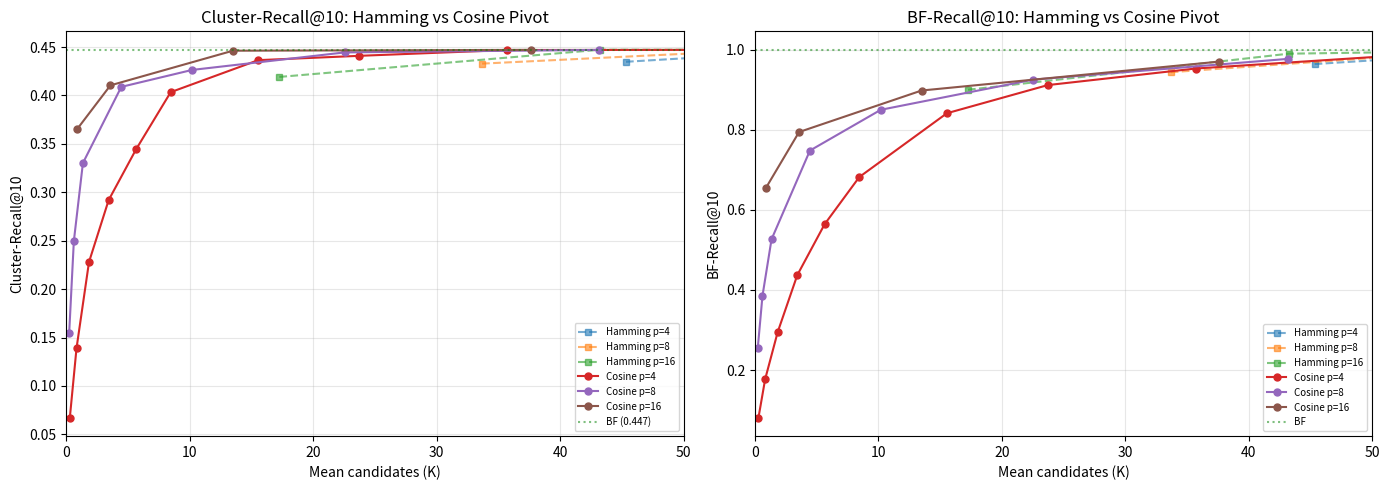


=== DuckDB 実装時のストレージコスト ===
  p= 4: 4 FLOAT columns × 75,162 rows = 1.1 MB
  p= 8: 8 FLOAT columns × 75,162 rows = 2.3 MB
  p=16: 16 FLOAT columns × 75,162 rows = 4.6 MB

=== 想定 SQL クエリ (p=16, thresh=0.15) ===

  SELECT face_id, embedding
  FROM face_detections
  WHERE model_name = 'insightface/buffalo_l'
    AND ABS(pivot_sim_0 - ?) <= 0.15
    AND ABS(pivot_sim_1 - ?) <= 0.15
    ...
    AND ABS(pivot_sim_15 - ?) <= 0.15
  -- 平均 ~13K 行を返す (75K の 18%)
  -- 512次元 × 13K = 26MB の転送 (全件 154MB の 17%)



In [13]:
# ハミング空間 vs コサイン空間 Pivot の比較可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ハミング空間 (セクション7の結果)
for n_p in PIVOT_COUNTS:
    sub = pivot_df[pivot_df["n_pivots"] == n_p]
    axes[0].plot(sub["mean_candidates"] / 1000, sub["Cluster-Recall@10"], "s--", 
                 label=f"Hamming p={n_p}", alpha=0.6, markersize=5)

# コサイン空間
for n_p in COS_PIVOT_COUNTS:
    sub = cos_pivot_df[(cos_pivot_df["n_pivots"] == n_p) & (cos_pivot_df["mean_candidates"] > 200)]
    axes[0].plot(sub["mean_candidates"] / 1000, sub["Cluster-Recall@10"], "o-", 
                 label=f"Cosine p={n_p}", markersize=5)

axes[0].axhline(y=cluster_recall_bf[10], color="green", linestyle=":", alpha=0.5, label=f"BF ({cluster_recall_bf[10]:.3f})")
axes[0].set_xlabel("Mean candidates (K)")
axes[0].set_ylabel("Cluster-Recall@10")
axes[0].set_title("Cluster-Recall@10: Hamming vs Cosine Pivot")
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 50)

# BF-Recall@10 比較
for n_p in PIVOT_COUNTS:
    sub = pivot_df[pivot_df["n_pivots"] == n_p]
    axes[1].plot(sub["mean_candidates"] / 1000, sub["BF-Recall@10"], "s--", 
                 label=f"Hamming p={n_p}", alpha=0.6, markersize=5)

for n_p in COS_PIVOT_COUNTS:
    sub = cos_pivot_df[(cos_pivot_df["n_pivots"] == n_p) & (cos_pivot_df["mean_candidates"] > 200)]
    axes[1].plot(sub["mean_candidates"] / 1000, sub["BF-Recall@10"], "o-", 
                 label=f"Cosine p={n_p}", markersize=5)

axes[1].axhline(y=1.0, color="green", linestyle=":", alpha=0.5, label="BF")
axes[1].set_xlabel("Mean candidates (K)")
axes[1].set_ylabel("BF-Recall@10")
axes[1].set_title("BF-Recall@10: Hamming vs Cosine Pivot")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 50)

plt.tight_layout()
plt.show()

# DuckDB 実装に必要なストレージサイズ
print("\n=== DuckDB 実装時のストレージコスト ===")
for n_p in COS_PIVOT_COUNTS:
    col_size_mb = N_TOTAL * n_p * 4 / 1024 / 1024
    print(f"  p={n_p:2d}: {n_p} FLOAT columns × {N_TOTAL:,} rows = {col_size_mb:.1f} MB")
    
print("\n=== 想定 SQL クエリ (p=16, thresh=0.15) ===")
print("""
  SELECT face_id, embedding
  FROM face_detections
  WHERE model_name = 'insightface/buffalo_l'
    AND ABS(pivot_sim_0 - ?) <= 0.15
    AND ABS(pivot_sim_1 - ?) <= 0.15
    ...
    AND ABS(pivot_sim_15 - ?) <= 0.15
  -- 平均 ~13K 行を返す (75K の 18%)
  -- 512次元 × 13K = 26MB の転送 (全件 154MB の 17%)
""")

## 11. バンド/セグメント方式 LSH（Band LSH）

lsh-cascade-poc の Overlap 方式や、従来の LSH バンディング手法に基づく実験。

### 基本アイデア
- 128bit ハッシュを b 個のバンド（セグメント）に分割（各バンドは r ビット）
- 2つのハッシュが**いずれかのバンドで完全一致**すれば候補とする（OR ロジック）
- オーバーラップ: バンド境界をずらして複数のバンド分割を重ね、再現率を向上
- さらにハミング距離閾値で候補を枝刈り

### 理論的背景
- バンド数 b, 各バンド r ビットの場合:
  - ハミング距離 d のペアが候補になる確率: `1 - (1 - (1 - d/n_bits)^r)^b`
  - r が小さい → 候補が多い（高 Recall、低削減率）
  - b が多い → 候補が多い（高 Recall）

### 実験構成
1. **基本バンドLSH**: 128bit を 8/16/32 セグメントに分割、完全一致バンドがあれば候補
2. **オーバーラップバンドLSH**: バンドを半分ずらして2重にカバー
3. **バンドLSH + ハミング閾値**: バンド候補をハミング距離で追加枝刈り
4. **ハイブリッド**: バンドLSH + コサイン Pivot の組み合わせ

In [14]:
# --- 11a. 基本バンド LSH ---
# 128bit ハッシュをセグメントに分割し、いずれかが完全一致すれば候補

def band_lsh_candidates(query_hash, all_hashes, n_bands, overlap=False):
    """
    バンド方式で候補を選択
    
    Args:
        query_hash: (n_bits,) uint8
        all_hashes: (N, n_bits) uint8
        n_bands: バンド数
        overlap: True の場合、半分ずらしたオーバーラップバンドも追加
    
    Returns:
        候補インデックスの集合
    """
    n_bits = len(query_hash)
    band_size = n_bits // n_bands
    
    candidates = set()
    
    # 基本バンド分割
    band_splits = [(i * band_size, (i + 1) * band_size) for i in range(n_bands)]
    
    # オーバーラップ: 半バンドずらし
    if overlap:
        offset = band_size // 2
        for i in range(n_bands - 1):
            start = i * band_size + offset
            end = start + band_size
            if end <= n_bits:
                band_splits.append((start, end))
    
    for start, end in band_splits:
        q_band = query_hash[start:end]
        matches = np.all(all_hashes[:, start:end] == q_band, axis=1)
        candidates.update(np.where(matches)[0])
    
    return candidates

def band_lsh_candidates_relaxed(query_hash, all_hashes, n_bands, max_diff_per_band=1, overlap=False):
    """
    緩和バンド方式: 各バンドで max_diff_per_band ビットまでの差異を許容
    完全一致ではなく「ほぼ一致」をバンドマッチとする
    """
    n_bits = len(query_hash)
    band_size = n_bits // n_bands
    
    candidates = set()
    band_splits = [(i * band_size, (i + 1) * band_size) for i in range(n_bands)]
    
    if overlap:
        offset = band_size // 2
        for i in range(n_bands - 1):
            start = i * band_size + offset
            end = start + band_size
            if end <= n_bits:
                band_splits.append((start, end))
    
    for start, end in band_splits:
        q_band = query_hash[start:end]
        band_diffs = np.sum(all_hashes[:, start:end] != q_band, axis=1)
        matches = band_diffs <= max_diff_per_band
        candidates.update(np.where(matches)[0])
    
    return candidates

# --- 実験: 基本バンドLSH ---
print("=== 11a. 基本バンドLSH (完全一致) ===")
BAND_CONFIGS = [
    (8, False, "8 bands (16bit each)"),
    (16, False, "16 bands (8bit each)"),
    (32, False, "32 bands (4bit each)"),
    (8, True, "8 bands + overlap"),
    (16, True, "16 bands + overlap"),
    (32, True, "32 bands + overlap"),
]

band_results = []
for n_bands, overlap, label in BAND_CONFIGS:
    cand_sizes = []
    bf_recalls = []
    cluster_recalls = []
    
    for qi, q in enumerate(queries):
        q_idx = q["query_idx"]
        cands = band_lsh_candidates(hashes[q_idx], hashes, n_bands, overlap=overlap)
        cands.discard(q_idx)
        cand_list = sorted(cands)
        cand_sizes.append(len(cand_list))
        
        if len(cand_list) > 0:
            cand_arr = np.array(cand_list)
            sims = embeddings[cand_arr] @ embeddings[q_idx]
            top_local = np.argsort(-sims)[:MAX_K]
            result_indices = cand_arr[top_local].tolist()
        else:
            result_indices = []
        
        gt_top = ground_truth[qi]["indices"]
        bf_recalls.append(compute_bf_recall(result_indices, gt_top, 10))
        cluster_recalls.append(compute_cluster_recall(result_indices, q["gt_indices"], 10))
    
    mean_c = np.mean(cand_sizes)
    band_results.append({
        "config": label,
        "n_bands": n_bands,
        "overlap": overlap,
        "max_diff": 0,
        "mean_candidates": mean_c,
        "min_candidates": int(np.min(cand_sizes)),
        "reduction_pct": (1 - mean_c / N_TOTAL) * 100,
        "BF-Recall@10": np.mean(bf_recalls),
        "Cluster-Recall@10": np.mean(cluster_recalls),
    })
    print(f"  {label:25s}: cands={mean_c:8.0f} (min={int(np.min(cand_sizes)):5d}), "
          f"reduce={100*(1 - mean_c/N_TOTAL):.1f}%, "
          f"BF-R@10={np.mean(bf_recalls):.4f}, Clust-R@10={np.mean(cluster_recalls):.4f}")

# --- 実験: 緩和バンドLSH ---
print("\n=== 11b. 緩和バンドLSH (バンド内差異許容) ===")
RELAXED_CONFIGS = [
    (8, 1, False, "8 bands, diff≤1"),
    (8, 2, False, "8 bands, diff≤2"),
    (8, 3, False, "8 bands, diff≤3"),
    (16, 1, False, "16 bands, diff≤1"),
    (16, 2, False, "16 bands, diff≤2"),
    (8, 1, True, "8 bands, diff≤1, overlap"),
    (8, 2, True, "8 bands, diff≤2, overlap"),
    (16, 1, True, "16 bands, diff≤1, overlap"),
]

for n_bands, max_diff, overlap, label in RELAXED_CONFIGS:
    cand_sizes = []
    bf_recalls = []
    cluster_recalls = []
    
    for qi, q in enumerate(queries):
        q_idx = q["query_idx"]
        cands = band_lsh_candidates_relaxed(hashes[q_idx], hashes, n_bands, max_diff_per_band=max_diff, overlap=overlap)
        cands.discard(q_idx)
        cand_list = sorted(cands)
        cand_sizes.append(len(cand_list))
        
        if len(cand_list) > 0:
            cand_arr = np.array(cand_list)
            sims = embeddings[cand_arr] @ embeddings[q_idx]
            top_local = np.argsort(-sims)[:MAX_K]
            result_indices = cand_arr[top_local].tolist()
        else:
            result_indices = []
        
        gt_top = ground_truth[qi]["indices"]
        bf_recalls.append(compute_bf_recall(result_indices, gt_top, 10))
        cluster_recalls.append(compute_cluster_recall(result_indices, q["gt_indices"], 10))
    
    mean_c = np.mean(cand_sizes)
    band_results.append({
        "config": label,
        "n_bands": n_bands,
        "overlap": overlap,
        "max_diff": max_diff,
        "mean_candidates": mean_c,
        "min_candidates": int(np.min(cand_sizes)),
        "reduction_pct": (1 - mean_c / N_TOTAL) * 100,
        "BF-Recall@10": np.mean(bf_recalls),
        "Cluster-Recall@10": np.mean(cluster_recalls),
    })
    print(f"  {label:30s}: cands={mean_c:8.0f} (min={int(np.min(cand_sizes)):5d}), "
          f"reduce={100*(1 - mean_c/N_TOTAL):.1f}%, "
          f"BF-R@10={np.mean(bf_recalls):.4f}, Clust-R@10={np.mean(cluster_recalls):.4f}")

band_df = pd.DataFrame(band_results)

=== 11a. 基本バンドLSH (完全一致) ===


  8 bands (16bit each)     : cands=      91 (min=    3), reduce=99.9%, BF-R@10=0.3302, Clust-R@10=0.1048


  16 bands (8bit each)     : cands=    5184 (min= 4031), reduce=93.1%, BF-R@10=0.8407, Clust-R@10=0.4058


  32 bands (4bit each)     : cands=   64919 (min=63163), reduce=13.6%, BF-R@10=0.9994, Clust-R@10=0.4472


  8 bands + overlap        : cands=     133 (min=    9), reduce=99.8%, BF-R@10=0.4284, Clust-R@10=0.1551


...

  16 bands, diff≤1              : cands=   32722 (min=30644), reduce=56.5%, BF-R@10=0.9852, Clust-R@10=0.4472


  16 bands, diff≤2              : cands=   68233 (min=66053), reduce=9.2%, BF-R@10=1.0000, Clust-R@10=0.4472


  8 bands, diff≤1, overlap      : cands=     676 (min=  221), reduce=99.1%, BF-R@10=0.7123, Clust-R@10=0.3310


  8 bands, diff≤2, overlap      : cands=    3048 (min= 1915), reduce=95.9%, BF-R@10=0.8870, Clust-R@10=0.4314


  16 bands, diff≤1, overlap     : cands=   45135 (min=43120), reduce=40.0%, BF-R@10=0.9957, Clust-R@10=0.4472


In [15]:
# --- 11c. バンドLSH + ハミング閾値 2段フィルタ ---
# バンド方式で候補を広めに取り、ハミング距離閾値でさらに枝刈り

print("=== 11c. バンドLSH + ハミング閾値 2段フィルタ ===")
BAND_HAMMING_CONFIGS = [
    # (n_bands, max_diff_per_band, overlap, hamming_thresh, label)
    (8, 2, False, 30, "8b diff≤2, ham≤30"),
    (8, 2, False, 25, "8b diff≤2, ham≤25"),
    (8, 2, False, 20, "8b diff≤2, ham≤20"),
    (8, 2, True, 25, "8b diff≤2 ovlp, ham≤25"),
    (8, 2, True, 20, "8b diff≤2 ovlp, ham≤20"),
    (16, 1, False, 30, "16b diff≤1, ham≤30"),
    (16, 1, False, 25, "16b diff≤1, ham≤25"),
    (16, 1, False, 20, "16b diff≤1, ham≤20"),
    (16, 1, True, 25, "16b diff≤1 ovlp, ham≤25"),
    (16, 1, True, 20, "16b diff≤1 ovlp, ham≤20"),
    (8, 3, False, 30, "8b diff≤3, ham≤30"),
    (8, 3, False, 25, "8b diff≤3, ham≤25"),
]

band_ham_results = []
for n_bands, max_diff, overlap, ham_thresh, label in BAND_HAMMING_CONFIGS:
    cand_sizes_stage1 = []
    cand_sizes_stage2 = []
    bf_recalls = []
    cluster_recalls = []
    
    for qi, q in enumerate(queries):
        q_idx = q["query_idx"]
        # Stage 1: バンドフィルタ
        if max_diff == 0:
            cands_s1 = band_lsh_candidates(hashes[q_idx], hashes, n_bands, overlap=overlap)
        else:
            cands_s1 = band_lsh_candidates_relaxed(hashes[q_idx], hashes, n_bands, max_diff_per_band=max_diff, overlap=overlap)
        cands_s1.discard(q_idx)
        cand_sizes_stage1.append(len(cands_s1))
        
        # Stage 2: ハミング距離フィルタ
        cand_arr_s1 = np.array(sorted(cands_s1))
        if len(cand_arr_s1) > 0:
            ham_dists = np.sum(hashes[cand_arr_s1] != hashes[q_idx], axis=1)
            keep = ham_dists <= ham_thresh
            cand_arr = cand_arr_s1[keep]
        else:
            cand_arr = np.array([], dtype=int)
        cand_sizes_stage2.append(len(cand_arr))
        
        # リランク
        if len(cand_arr) > 0:
            sims = embeddings[cand_arr] @ embeddings[q_idx]
            top_local = np.argsort(-sims)[:MAX_K]
            result_indices = cand_arr[top_local].tolist()
        else:
            result_indices = []
        
        gt_top = ground_truth[qi]["indices"]
        bf_recalls.append(compute_bf_recall(result_indices, gt_top, 10))
        cluster_recalls.append(compute_cluster_recall(result_indices, q["gt_indices"], 10))
    
    mean_s1 = np.mean(cand_sizes_stage1)
    mean_s2 = np.mean(cand_sizes_stage2)
    band_ham_results.append({
        "config": label,
        "mean_stage1": mean_s1,
        "mean_candidates": mean_s2,
        "min_candidates": int(np.min(cand_sizes_stage2)),
        "reduction_pct": (1 - mean_s2 / N_TOTAL) * 100,
        "BF-Recall@10": np.mean(bf_recalls),
        "Cluster-Recall@10": np.mean(cluster_recalls),
    })
    print(f"  {label:30s}: s1={mean_s1:8.0f} → s2={mean_s2:8.0f} (min={int(np.min(cand_sizes_stage2)):5d}), "
          f"reduce={100*(1 - mean_s2/N_TOTAL):.1f}%, "
          f"BF-R@10={np.mean(bf_recalls):.4f}, Clust-R@10={np.mean(cluster_recalls):.4f}")

band_ham_df = pd.DataFrame(band_ham_results)

=== 11c. バンドLSH + ハミング閾値 2段フィルタ ===


  8b diff≤2, ham≤30             : s1=    1916 → s2=     179 (min=    0), reduce=99.8%, BF-R@10=0.6938, Clust-R@10=0.2941


  8b diff≤2, ham≤25             : s1=    1916 → s2=     104 (min=    0), reduce=99.9%, BF-R@10=0.5056, Clust-R@10=0.1732


  8b diff≤2, ham≤20             : s1=    1916 → s2=      64 (min=    0), reduce=99.9%, BF-R@10=0.3309, Clust-R@10=0.0882


  8b diff≤2 ovlp, ham≤25        : s1=    3048 → s2=     104 (min=    0), reduce=99.9%, BF-R@10=0.5056, Clust-R@10=0.1732


...

  16b diff≤1, ham≤20            : s1=   32722 → s2=      64 (min=    0), reduce=99.9%, BF-R@10=0.3309, Clust-R@10=0.0882


  16b diff≤1 ovlp, ham≤25       : s1=   45135 → s2=     104 (min=    0), reduce=99.9%, BF-R@10=0.5056, Clust-R@10=0.1732


  16b diff≤1 ovlp, ham≤20       : s1=   45135 → s2=      64 (min=    0), reduce=99.9%, BF-R@10=0.3309, Clust-R@10=0.0882


  8b diff≤3, ham≤30             : s1=    7184 → s2=     181 (min=    0), reduce=99.8%, BF-R@10=0.7000, Clust-R@10=0.2973


  8b diff≤3, ham≤25             : s1=    7184 → s2=     104 (min=    0), reduce=99.9%, BF-R@10=0.5056, Clust-R@10=0.1732


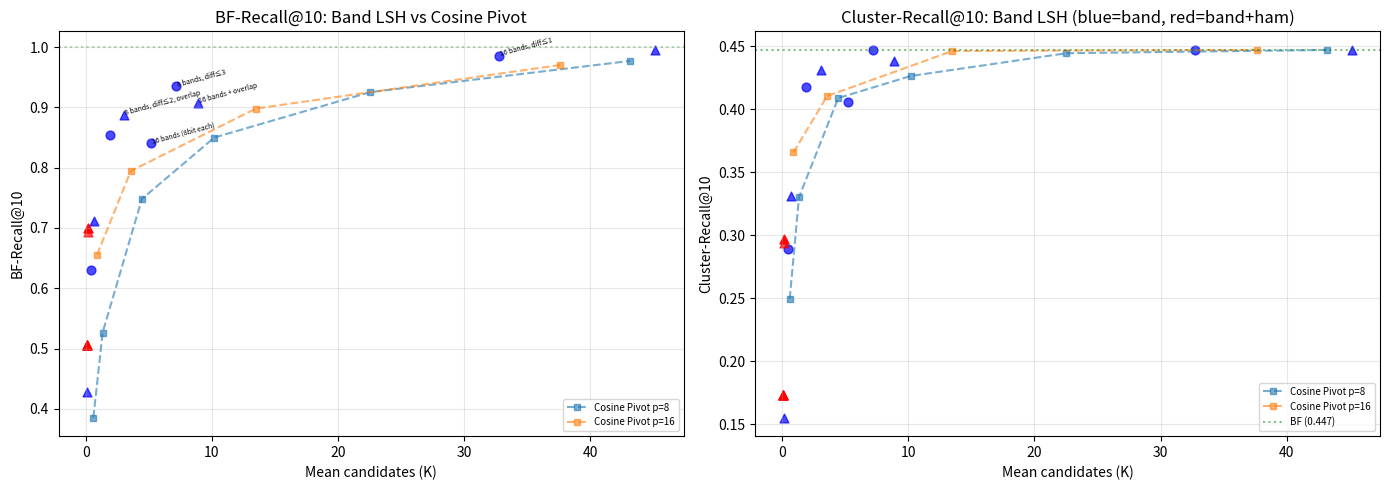


=== バンドLSH ベスト構成 (Cluster-R@10 ≥ 0.44 かつ reduce > 50%) ===
  8 bands, diff≤3                    : cands=    7184, reduce=90.4%, BF-R@10=0.9352, Clust-R@10=0.4472
  16 bands, diff≤1                   : cands=   32722, reduce=56.5%, BF-R@10=0.9852, Clust-R@10=0.4472


In [16]:
# --- 11d. バンドLSH 可視化 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 全手法をプロット
all_band = pd.concat([band_df, band_ham_df], ignore_index=True)

# 候補数 vs BF-Recall@10
for _, row in all_band.iterrows():
    c = row["mean_candidates"]
    if c > 100 and c < 60000:
        color = "red" if "ham" in str(row.get("config", "")) else "blue"
        marker = "^" if row.get("overlap", False) or "ovlp" in str(row.get("config", "")) else "o"
        axes[0].scatter(c / 1000, row["BF-Recall@10"], c=color, marker=marker, s=40, alpha=0.7)
        if c > 3000 and c < 40000:
            axes[0].annotate(row["config"], (c/1000, row["BF-Recall@10"]), fontsize=5, rotation=15)

# コサイン Pivot 比較
for n_p in [8, 16]:
    sub = cos_pivot_df[(cos_pivot_df["n_pivots"] == n_p) & (cos_pivot_df["mean_candidates"] > 500)]
    axes[0].plot(sub["mean_candidates"] / 1000, sub["BF-Recall@10"], "s--", 
                 label=f"Cosine Pivot p={n_p}", alpha=0.6, markersize=4)

axes[0].axhline(y=1.0, color="green", linestyle=":", alpha=0.3)
axes[0].set_xlabel("Mean candidates (K)")
axes[0].set_ylabel("BF-Recall@10")
axes[0].set_title("BF-Recall@10: Band LSH vs Cosine Pivot")
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

# 候補数 vs Cluster-Recall@10
for _, row in all_band.iterrows():
    c = row["mean_candidates"]
    if c > 100 and c < 60000:
        color = "red" if "ham" in str(row.get("config", "")) else "blue"
        marker = "^" if row.get("overlap", False) or "ovlp" in str(row.get("config", "")) else "o"
        axes[1].scatter(c / 1000, row["Cluster-Recall@10"], c=color, marker=marker, s=40, alpha=0.7)

for n_p in [8, 16]:
    sub = cos_pivot_df[(cos_pivot_df["n_pivots"] == n_p) & (cos_pivot_df["mean_candidates"] > 500)]
    axes[1].plot(sub["mean_candidates"] / 1000, sub["Cluster-Recall@10"], "s--", 
                 label=f"Cosine Pivot p={n_p}", alpha=0.6, markersize=4)

axes[1].axhline(y=cluster_recall_bf[10], color="green", linestyle=":", alpha=0.5, label=f"BF ({cluster_recall_bf[10]:.3f})")
axes[1].set_xlabel("Mean candidates (K)")
axes[1].set_ylabel("Cluster-Recall@10")
axes[1].set_title("Cluster-Recall@10: Band LSH (blue=band, red=band+ham)")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ベスト構成まとめ
print("\n=== バンドLSH ベスト構成 (Cluster-R@10 ≥ 0.44 かつ reduce > 50%) ===")
good = all_band[(all_band["Cluster-Recall@10"] >= 0.44) & (all_band["reduction_pct"] > 50)]
if len(good) > 0:
    good_sorted = good.sort_values("reduction_pct", ascending=False)
    for _, row in good_sorted.iterrows():
        print(f"  {row['config']:35s}: cands={row['mean_candidates']:8.0f}, "
              f"reduce={row['reduction_pct']:.1f}%, "
              f"BF-R@10={row['BF-Recall@10']:.4f}, Clust-R@10={row['Cluster-Recall@10']:.4f}")
else:
    print("  Cluster-R@10 >= 0.44 かつ reduce > 50% を満たす構成なし")
    good = all_band[(all_band["Cluster-Recall@10"] >= 0.43) & (all_band["reduction_pct"] > 40)]
    good_sorted = good.sort_values("reduction_pct", ascending=False)
    for _, row in good_sorted.head(8).iterrows():
        print(f"  {row['config']:35s}: cands={row['mean_candidates']:8.0f}, "
              f"reduce={row['reduction_pct']:.1f}%, "
              f"BF-R@10={row['BF-Recall@10']:.4f}, Clust-R@10={row['Cluster-Recall@10']:.4f}")

## 12. 新手法提案: Multi-Probe バンドLSH

### 課題
基本バンドLSHでは「完全一致」のみを候補とするため、1ビットの差で候補から漏れる。
Multi-Probe LSH では、クエリのハッシュを少しだけ変更した「プローブ」を複数生成し、
それぞれでバンドマッチングを行うことで、追加ハッシュテーブルなしに Recall を向上させる。

### アイデア
1. クエリハッシュの各ビットについて、ITQ 回転後の射影値（確信度）が低いビットを特定
2. 確信度が低いビット（決定境界に近い）を反転させたプローブを生成
3. 各プローブでバンドマッチングを実行し、候補を合体
4. 最終的にハミング距離閾値で枝刈り

### セクション10のコサイン Pivot との違い
- コサイン Pivot は**元の埋め込み空間**で事前計算が必要（16カラム追加）
- Multi-Probe バンドLSH は**ハッシュ空間のみ**で完結（追加ストレージ不要）
- DB 実装では**整数カラム**（バンドハッシュ値）を使い、等値検索で候補生成

In [17]:
# --- 12. Multi-Probe バンド LSH ---
# ITQ の射影値（確信度）を使って低確信度ビットを反転させたプローブを生成

def multi_probe_band_lsh(query_emb, all_hashes, itq_model, n_bands, 
                          n_probes=3, ham_thresh=None, overlap=False):
    """
    Multi-Probe Band LSH
    
    Args:
        query_emb: クエリ埋め込み (dim,)
        all_hashes: 全ドキュメントハッシュ (N, n_bits)
        itq_model: ITQLSH インスタンス（確信度計算用）
        n_bands: バンド数
        n_probes: プローブ数（元のハッシュ + n_probes 個の反転ハッシュ）
        ham_thresh: ハミング距離閾値（None なら適用しない）
        overlap: オーバーラップバンド
    
    Returns:
        候補インデックスの配列
    """
    # 確信度付きハッシュ変換
    query_hash, projections = itq_model.transform_with_confidence(query_emb)
    
    # プローブ生成: 確信度が低いビットを反転
    abs_proj = np.abs(projections)
    low_confidence_bits = np.argsort(abs_proj)  # 確信度昇順
    
    candidates = set()
    
    # 元のハッシュでバンドマッチング
    candidates.update(band_lsh_candidates(query_hash, all_hashes, n_bands, overlap=overlap))
    
    # プローブでバンドマッチング
    for probe_i in range(n_probes):
        probe_hash = query_hash.copy()
        # 確信度が低いビットを1つ反転
        bit_to_flip = low_confidence_bits[probe_i]
        probe_hash[bit_to_flip] = 1 - probe_hash[bit_to_flip]
        candidates.update(band_lsh_candidates(probe_hash, all_hashes, n_bands, overlap=overlap))
    
    cand_arr = np.array(sorted(candidates))
    
    # ハミング距離閾値で枝刈り
    if ham_thresh is not None and len(cand_arr) > 0:
        ham_dists = np.sum(all_hashes[cand_arr] != query_hash, axis=1)
        cand_arr = cand_arr[ham_dists <= ham_thresh]
    
    return cand_arr

# 実験: Multi-Probe Band LSH
print("=== 12. Multi-Probe Band LSH ===")
MP_CONFIGS = [
    # (n_bands, n_probes, ham_thresh, overlap, label)
    (8, 0, None, False, "8b, 0 probes (baseline)"),
    (8, 3, None, False, "8b, 3 probes"),
    (8, 5, None, False, "8b, 5 probes"),
    (8, 8, None, False, "8b, 8 probes"),
    (8, 3, 30, False, "8b, 3 probes, ham≤30"),
    (8, 5, 25, False, "8b, 5 probes, ham≤25"),
    (8, 8, 25, False, "8b, 8 probes, ham≤25"),
    (8, 8, 30, False, "8b, 8 probes, ham≤30"),
    (16, 0, None, False, "16b, 0 probes (baseline)"),
    (16, 3, None, False, "16b, 3 probes"),
    (16, 5, None, False, "16b, 5 probes"),
    (16, 8, None, False, "16b, 8 probes"),
    (16, 5, 30, False, "16b, 5 probes, ham≤30"),
    (16, 8, 30, False, "16b, 8 probes, ham≤30"),
    (16, 8, 25, False, "16b, 8 probes, ham≤25"),
    (8, 5, 30, True, "8b ovlp, 5 probes, ham≤30"),
    (8, 8, 30, True, "8b ovlp, 8 probes, ham≤30"),
]

mp_results = []
for n_bands, n_probes, ham_thresh, overlap, label in MP_CONFIGS:
    cand_sizes = []
    bf_recalls = []
    cluster_recalls = []
    
    for qi, q in enumerate(queries):
        q_idx = q["query_idx"]
        cand_arr = multi_probe_band_lsh(
            embeddings[q_idx], hashes, itq_128, 
            n_bands=n_bands, n_probes=n_probes, 
            ham_thresh=ham_thresh, overlap=overlap
        )
        # 自分自身を除外
        cand_arr = cand_arr[cand_arr != q_idx]
        cand_sizes.append(len(cand_arr))
        
        if len(cand_arr) > 0:
            sims = embeddings[cand_arr] @ embeddings[q_idx]
            top_local = np.argsort(-sims)[:MAX_K]
            result_indices = cand_arr[top_local].tolist()
        else:
            result_indices = []
        
        gt_top = ground_truth[qi]["indices"]
        bf_recalls.append(compute_bf_recall(result_indices, gt_top, 10))
        cluster_recalls.append(compute_cluster_recall(result_indices, q["gt_indices"], 10))
    
    mean_c = np.mean(cand_sizes)
    mp_results.append({
        "config": label,
        "mean_candidates": mean_c,
        "min_candidates": int(np.min(cand_sizes)),
        "reduction_pct": (1 - mean_c / N_TOTAL) * 100,
        "BF-Recall@10": np.mean(bf_recalls),
        "Cluster-Recall@10": np.mean(cluster_recalls),
    })
    print(f"  {label:35s}: cands={mean_c:8.0f} (min={int(np.min(cand_sizes)):5d}), "
          f"reduce={100*(1 - mean_c/N_TOTAL):.1f}%, "
          f"BF-R@10={np.mean(bf_recalls):.4f}, Clust-R@10={np.mean(cluster_recalls):.4f}")

mp_df = pd.DataFrame(mp_results)

=== 12. Multi-Probe Band LSH ===


  8b, 0 probes (baseline)            : cands=      91 (min=    3), reduce=99.9%, BF-R@10=0.3302, Clust-R@10=0.1048


  8b, 3 probes                       : cands=     109 (min=    4), reduce=99.9%, BF-R@10=0.3722, Clust-R@10=0.1304


  8b, 5 probes                       : cands=     118 (min=    5), reduce=99.8%, BF-R@10=0.3907, Clust-R@10=0.1467


  8b, 8 probes                       : cands=     134 (min=    9), reduce=99.8%, BF-R@10=0.4210, Clust-R@10=0.1585


...

  16b, 5 probes, ham≤30              : cands=     178 (min=    0), reduce=99.8%, BF-R@10=0.6895, Clust-R@10=0.2985


  16b, 8 probes, ham≤30              : cands=     179 (min=    0), reduce=99.8%, BF-R@10=0.6901, Clust-R@10=0.2985


  16b, 8 probes, ham≤25              : cands=     104 (min=    0), reduce=99.9%, BF-R@10=0.5049, Clust-R@10=0.1732


  8b ovlp, 5 probes, ham≤30          : cands=     100 (min=    0), reduce=99.9%, BF-R@10=0.4673, Clust-R@10=0.1802


  8b ovlp, 8 probes, ham≤30          : cands=     107 (min=    0), reduce=99.9%, BF-R@10=0.4895, Clust-R@10=0.1916


## 13. 新手法提案: バンドLSH のDB実装シミュレーション

バンドLSH を実際のDBで実装する場合、各バンドのビット列を**整数値**として保存し、
`WHERE band_0 = ? OR band_1 = ? OR ... OR band_7 = ?` で候補を取得する。

ここでは、DB 実装を想定したシミュレーションを行う:
- 各バンドの整数値を計算（8band = 8個の16bit整数 = 8 INT カラム）
- OR 条件の数 = バンド数 × (1 + n_probes)
- DB のインデックスは各カラムに作成（B-tree）

### コサイン Pivot との比較
| 観点 | バンドLSH | コサイン Pivot |
|---|---|---|
| 追加カラム | 8-16 INT | 16 FLOAT |
| クエリ条件 | OR (等値検索) | AND (範囲検索) |
| インデックス | 各カラムに B-tree | 各カラムに B-tree |
| 候補制御 | probes/bands/diff で調整 | threshold で調整 |
| 追加計算 | なし (ハッシュのみ) | 16 回の cos_sim |

In [18]:
# --- 13. DB実装シミュレーション ---
# バンドハッシュ値を整数に変換して、等値検索をシミュレート

def bits_to_int(bits):
    """ビット配列を整数に変換"""
    result = 0
    for b in bits:
        result = (result << 1) | int(b)
    return result

def build_band_index(all_hashes, n_bands):
    """バンドインデックスを構築（DB テーブルのシミュレーション）"""
    n_bits = all_hashes.shape[1]
    band_size = n_bits // n_bands
    
    # 各バンドの整数値を計算
    band_values = np.zeros((len(all_hashes), n_bands), dtype=np.int64)
    for b in range(n_bands):
        start = b * band_size
        end = (b + 1) * band_size
        for i in range(len(all_hashes)):
            band_values[i, b] = bits_to_int(all_hashes[i, start:end])
    
    # 各バンドの逆引きインデックス（ハッシュテーブル = DB B-tree相当）
    band_index = []
    for b in range(n_bands):
        idx = {}
        for i in range(len(all_hashes)):
            val = band_values[i, b]
            if val not in idx:
                idx[val] = []
            idx[val].append(i)
        band_index.append(idx)
    
    return band_values, band_index

def db_band_search(query_hash, band_values, band_index, n_bands, 
                    n_probes=0, itq_model=None, query_emb=None, ham_thresh=None):
    """
    DB 実装相当のバンドLSH検索
    等値検索（SELECT WHERE band_i = ?）のシミュレーション
    """
    n_bits = len(query_hash)
    band_size = n_bits // n_bands
    
    candidates = set()
    n_or_conditions = 0  # DB の OR 条件数をカウント
    
    # プローブリスト生成
    probe_hashes = [query_hash]
    if n_probes > 0 and itq_model is not None and query_emb is not None:
        _, projections = itq_model.transform_with_confidence(query_emb)
        abs_proj = np.abs(projections)
        low_confidence_bits = np.argsort(abs_proj)
        for p in range(n_probes):
            probe = query_hash.copy()
            probe[low_confidence_bits[p]] = 1 - probe[low_confidence_bits[p]]
            probe_hashes.append(probe)
    
    # 各プローブ × 各バンドで等値検索
    for probe in probe_hashes:
        for b in range(n_bands):
            start = b * band_size
            end = (b + 1) * band_size
            val = bits_to_int(probe[start:end])
            n_or_conditions += 1
            if val in band_index[b]:
                candidates.update(band_index[b][val])
    
    cand_arr = np.array(sorted(candidates))
    
    # ハミング距離閾値
    if ham_thresh is not None and len(cand_arr) > 0:
        ham_dists = np.sum(hashes[cand_arr] != query_hash, axis=1)
        cand_arr = cand_arr[ham_dists <= ham_thresh]
    
    return cand_arr, n_or_conditions

# インデックス構築
print("バンドインデックス構築中...")
band_values_8, band_index_8 = build_band_index(hashes, 8)
band_values_16, band_index_16 = build_band_index(hashes, 16)
print(f"  8 bands: 各バンド {hashes.shape[1]//8}bit, ユニーク値数 = {[len(idx) for idx in band_index_8]}")
print(f"  16 bands: 各バンド {hashes.shape[1]//16}bit, ユニーク値数 = {[len(idx) for idx in band_index_16]}")

# DB検索シミュレーション
print("\n=== 13. DB実装シミュレーション ===")
DB_CONFIGS = [
    (8, band_values_8, band_index_8, 0, None, "8b exact"),
    (8, band_values_8, band_index_8, 3, None, "8b + 3 probes"),
    (8, band_values_8, band_index_8, 5, None, "8b + 5 probes"),
    (8, band_values_8, band_index_8, 5, 30, "8b + 5 probes, ham≤30"),
    (8, band_values_8, band_index_8, 5, 25, "8b + 5 probes, ham≤25"),
    (8, band_values_8, band_index_8, 8, 30, "8b + 8 probes, ham≤30"),
    (8, band_values_8, band_index_8, 8, 25, "8b + 8 probes, ham≤25"),
    (16, band_values_16, band_index_16, 0, None, "16b exact"),
    (16, band_values_16, band_index_16, 3, None, "16b + 3 probes"),
    (16, band_values_16, band_index_16, 5, None, "16b + 5 probes"),
    (16, band_values_16, band_index_16, 5, 30, "16b + 5 probes, ham≤30"),
    (16, band_values_16, band_index_16, 8, 30, "16b + 8 probes, ham≤30"),
    (16, band_values_16, band_index_16, 8, 25, "16b + 8 probes, ham≤25"),
]

db_results = []
for n_bands, bv, bi, n_probes, ham_thresh, label in DB_CONFIGS:
    cand_sizes = []
    bf_recalls = []
    cluster_recalls = []
    or_counts = []
    search_times = []
    
    for qi, q in enumerate(queries):
        q_idx = q["query_idx"]
        t0 = time.perf_counter()
        cand_arr, n_or = db_band_search(
            hashes[q_idx], bv, bi, n_bands,
            n_probes=n_probes, itq_model=itq_128, 
            query_emb=embeddings[q_idx], ham_thresh=ham_thresh
        )
        cand_arr = cand_arr[cand_arr != q_idx]
        search_times.append((time.perf_counter() - t0) * 1000)
        cand_sizes.append(len(cand_arr))
        or_counts.append(n_or)
        
        if len(cand_arr) > 0:
            sims = embeddings[cand_arr] @ embeddings[q_idx]
            top_local = np.argsort(-sims)[:MAX_K]
            result_indices = cand_arr[top_local].tolist()
        else:
            result_indices = []
        
        gt_top = ground_truth[qi]["indices"]
        bf_recalls.append(compute_bf_recall(result_indices, gt_top, 10))
        cluster_recalls.append(compute_cluster_recall(result_indices, q["gt_indices"], 10))
    
    mean_c = np.mean(cand_sizes)
    db_results.append({
        "config": label,
        "n_or_conditions": or_counts[0],
        "mean_candidates": mean_c,
        "min_candidates": int(np.min(cand_sizes)),
        "reduction_pct": (1 - mean_c / N_TOTAL) * 100,
        "BF-Recall@10": np.mean(bf_recalls),
        "Cluster-Recall@10": np.mean(cluster_recalls),
        "mean_search_ms": np.mean(search_times),
    })
    print(f"  {label:30s} (OR={or_counts[0]:3d}): cands={mean_c:8.0f}, "
          f"reduce={100*(1 - mean_c/N_TOTAL):.1f}%, "
          f"BF-R@10={np.mean(bf_recalls):.4f}, Clust-R@10={np.mean(cluster_recalls):.4f}, "
          f"{np.mean(search_times):.1f}ms")

db_df = pd.DataFrame(db_results)

# DB ストレージコスト
print(f"\n=== DB ストレージコスト ===")
print(f"  8 bands × 16bit INT: {N_TOTAL * 8 * 2 / 1024:.0f} KB ({N_TOTAL * 8 * 2 / 1024 / 1024:.1f} MB)")
print(f"  16 bands × 8bit INT: {N_TOTAL * 16 * 1 / 1024:.0f} KB ({N_TOTAL * 16 * 1 / 1024 / 1024:.1f} MB)")
print(f"  比較: Cosine Pivot 16 FLOAT: {N_TOTAL * 16 * 4 / 1024 / 1024:.1f} MB")
print(f"  比較: 元の embedding 512×FLOAT: {N_TOTAL * 512 * 4 / 1024 / 1024:.1f} MB")

バンドインデックス構築中...


  8 bands: 各バンド 16bit, ユニーク値数 = [38766, 38514, 39053, 38949, 37968, 38218, 38085, 37439]
  16 bands: 各バンド 8bit, ユニーク値数 = [256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256]

=== 13. DB実装シミュレーション ===
  8b exact                       (OR=  8): cands=      91, reduce=99.9%, BF-R@10=0.3302, Clust-R@10=0.1048, 0.0ms
  8b + 3 probes                  (OR= 32): cands=     109, reduce=99.9%, BF-R@10=0.3722, Clust-R@10=0.1304, 0.1ms
  8b + 5 probes                  (OR= 48): cands=     118, reduce=99.8%, BF-R@10=0.3907, Clust-R@10=0.1467, 0.2ms
  8b + 5 probes, ham≤30          (OR= 48): cands=      79, reduce=99.9%, BF-R@10=0.3840, Clust-R@10=0.1425, 0.2ms
  8b + 5 probes, ham≤25          (OR= 48): cands=      68, reduce=99.9%, BF-R@10=0.3494, Clust-R@10=0.1137, 0.2ms


  8b + 8 probes, ham≤30          (OR= 72): cands=      86, reduce=99.9%, BF-R@10=0.4142, Clust-R@10=0.1540, 0.3ms
  8b + 8 probes, ham≤25          (OR= 72): cands=      72, reduce=99.9%, BF-R@10=0.3722, Clust-R@10=0.1231, 0.3ms


  16b exact                      (OR= 16): cands=    5184, reduce=93.1%, BF-R@10=0.8407, Clust-R@10=0.4058, 1.6ms


  16b + 3 probes                 (OR= 64): cands=    6043, reduce=92.0%, BF-R@10=0.8549, Clust-R@10=0.4107, 2.6ms


  16b + 5 probes                 (OR= 96): cands=    6622, reduce=91.2%, BF-R@10=0.8648, Clust-R@10=0.4133, 3.2ms


  16b + 5 probes, ham≤30         (OR= 96): cands=     178, reduce=99.8%, BF-R@10=0.6895, Clust-R@10=0.2985, 3.0ms


  16b + 8 probes, ham≤30         (OR=144): cands=     179, reduce=99.8%, BF-R@10=0.6901, Clust-R@10=0.2985, 3.7ms


  16b + 8 probes, ham≤25         (OR=144): cands=     104, reduce=99.9%, BF-R@10=0.5049, Clust-R@10=0.1732, 3.1ms

=== DB ストレージコスト ===
  8 bands × 16bit INT: 1174 KB (1.1 MB)
  16 bands × 8bit INT: 1174 KB (1.1 MB)
  比較: Cosine Pivot 16 FLOAT: 4.6 MB
  比較: 元の embedding 512×FLOAT: 146.8 MB


## 14. 全手法の総合比較

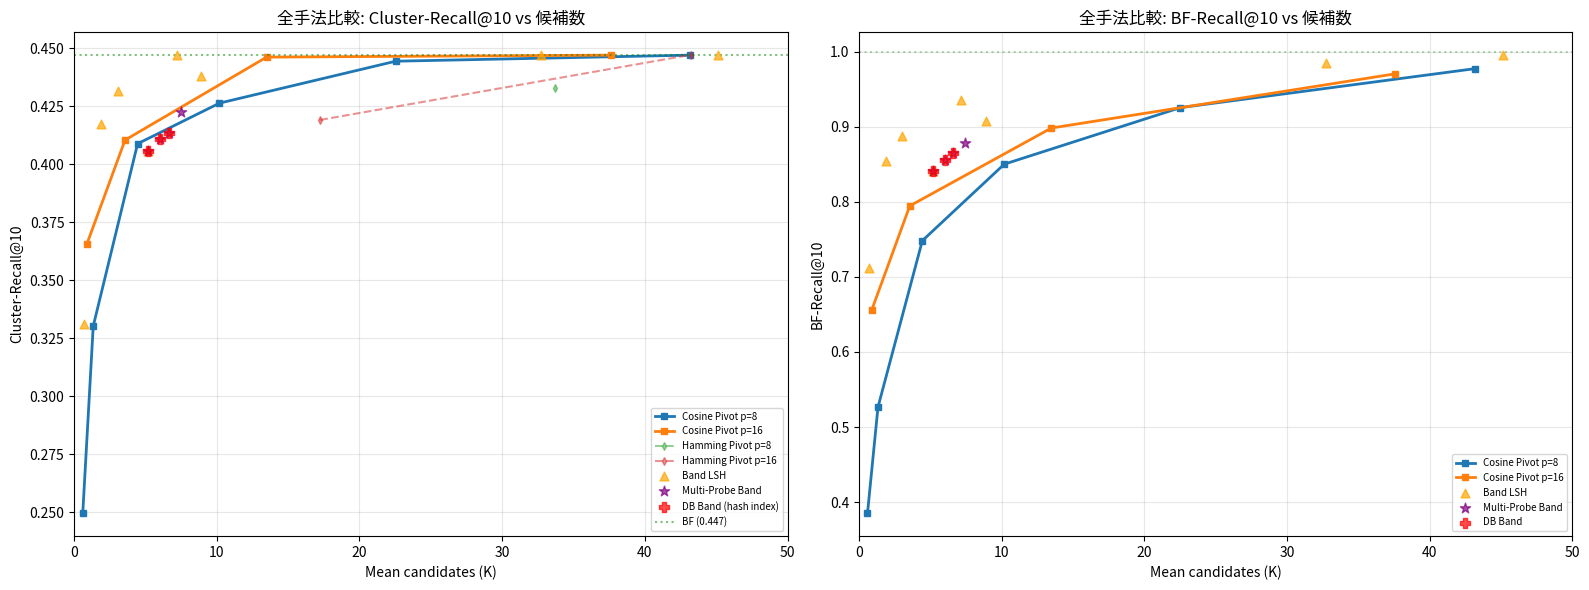


全手法パレート最適構成（Cluster-R@10 ≥ 0.43 の中で候補数が少ない順）

Method                                        | Category        |    Cands |  Reduce% |  BF-R@10 |  C-R@10 |   DB条件
--------------------------------------------------------------------------------------------------------------
8 bands, diff≤2, overlap                      | Band LSH        |     3048 |    95.9% |   0.8870 |  0.4314 |      0
8 bands, diff≤3                               | Band LSH        |     7184 |    90.4% |   0.9352 |  0.4472 |      0
16 bands + overlap                            | Band LSH        |     8895 |    88.2% |   0.9074 |  0.4381 |      0
Cosine Pivot p=16 t=0.15                      | Cosine Pivot    |    13491 |    82.1% |   0.8981 |  0.4462 |     16
Cosine Pivot p=4 t=0.10                       | Cosine Pivot    |    15541 |    79.3% |   0.8414 |  0.4364 |      4
Cosine Pivot p=8 t=0.15                       | Cosine Pivot    |    22534 |    70.0% |   0.9253 |  0.4444 |      8
Cosine Pivot p=4 t=0.12       

In [19]:
# --- 14. 全手法の統合比較 ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 候補数 vs Cluster-Recall@10 の包括プロット
# コサイン Pivot
for n_p in [8, 16]:
    sub = cos_pivot_df[(cos_pivot_df["n_pivots"] == n_p) & 
                       (cos_pivot_df["mean_candidates"] > 500) & 
                       (cos_pivot_df["mean_candidates"] < 50000)]
    axes[0].plot(sub["mean_candidates"] / 1000, sub["Cluster-Recall@10"], "s-", 
                 label=f"Cosine Pivot p={n_p}", markersize=5, linewidth=2)

# ハミング Pivot (セクション7)
for n_p in [8, 16]:
    sub = pivot_df[(pivot_df["n_pivots"] == n_p) & (pivot_df["mean_candidates"] < 50000)]
    axes[0].plot(sub["mean_candidates"] / 1000, sub["Cluster-Recall@10"], "d--", 
                 label=f"Hamming Pivot p={n_p}", markersize=4, alpha=0.5)

# バンドLSH (セクション11のベスト)
band_good = all_band[(all_band["mean_candidates"] > 500) & (all_band["mean_candidates"] < 50000)]
if len(band_good) > 0:
    axes[0].scatter(band_good["mean_candidates"] / 1000, band_good["Cluster-Recall@10"],
                   c="orange", marker="^", s=40, label="Band LSH", alpha=0.7, zorder=5)

# Multi-Probe (セクション12)
mp_good = mp_df[(mp_df["mean_candidates"] > 500) & (mp_df["mean_candidates"] < 50000)]
if len(mp_good) > 0:
    axes[0].scatter(mp_good["mean_candidates"] / 1000, mp_good["Cluster-Recall@10"],
                   c="purple", marker="*", s=60, label="Multi-Probe Band", alpha=0.7, zorder=5)

# DB シミュレーション (セクション13)
db_good = db_df[(db_df["mean_candidates"] > 500) & (db_df["mean_candidates"] < 50000)]
if len(db_good) > 0:
    axes[0].scatter(db_good["mean_candidates"] / 1000, db_good["Cluster-Recall@10"],
                   c="red", marker="P", s=60, label="DB Band (hash index)", alpha=0.7, zorder=5)

axes[0].axhline(y=cluster_recall_bf[10], color="green", linestyle=":", alpha=0.5, 
                label=f"BF ({cluster_recall_bf[10]:.3f})")
axes[0].set_xlabel("Mean candidates (K)")
axes[0].set_ylabel("Cluster-Recall@10")
axes[0].set_title("全手法比較: Cluster-Recall@10 vs 候補数")
axes[0].legend(fontsize=7, loc="lower right")
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 50)

# 候補数 vs BF-Recall@10
for n_p in [8, 16]:
    sub = cos_pivot_df[(cos_pivot_df["n_pivots"] == n_p) & 
                       (cos_pivot_df["mean_candidates"] > 500) & 
                       (cos_pivot_df["mean_candidates"] < 50000)]
    axes[1].plot(sub["mean_candidates"] / 1000, sub["BF-Recall@10"], "s-", 
                 label=f"Cosine Pivot p={n_p}", markersize=5, linewidth=2)

if len(band_good) > 0:
    axes[1].scatter(band_good["mean_candidates"] / 1000, band_good["BF-Recall@10"],
                   c="orange", marker="^", s=40, label="Band LSH", alpha=0.7, zorder=5)

if len(mp_good) > 0:
    axes[1].scatter(mp_good["mean_candidates"] / 1000, mp_good["BF-Recall@10"],
                   c="purple", marker="*", s=60, label="Multi-Probe Band", alpha=0.7, zorder=5)

if len(db_good) > 0:
    axes[1].scatter(db_good["mean_candidates"] / 1000, db_good["BF-Recall@10"],
                   c="red", marker="P", s=60, label="DB Band", alpha=0.7, zorder=5)

axes[1].axhline(y=1.0, color="green", linestyle=":", alpha=0.3)
axes[1].set_xlabel("Mean candidates (K)")
axes[1].set_ylabel("BF-Recall@10")
axes[1].set_title("全手法比較: BF-Recall@10 vs 候補数")
axes[1].legend(fontsize=7, loc="lower right")
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 50)

plt.tight_layout()
plt.show()

# === 最終テーブル: 全手法のパレート最適構成 ===
print("\n" + "=" * 100)
print("全手法パレート最適構成（Cluster-R@10 ≥ 0.43 の中で候補数が少ない順）")
print("=" * 100)

all_methods = []

# コサイン Pivot
for _, row in cos_pivot_df.iterrows():
    if row["Cluster-Recall@10"] >= 0.43:
        all_methods.append({
            "Method": f"Cosine Pivot p={int(row['n_pivots'])} t={row['threshold']:.2f}",
            "Category": "Cosine Pivot",
            "Candidates": row["mean_candidates"],
            "Reduction%": row["reduction_pct"],
            "BF-R@10": row["BF-Recall@10"],
            "Clust-R@10": row["Cluster-Recall@10"],
            "DB条件数": int(row["n_pivots"]),
            "DB条件タイプ": "AND (range)",
        })

# バンドLSH
for _, row in all_band.iterrows():
    if row["Cluster-Recall@10"] >= 0.43:
        all_methods.append({
            "Method": row["config"],
            "Category": "Band LSH",
            "Candidates": row["mean_candidates"],
            "Reduction%": row["reduction_pct"],
            "BF-R@10": row["BF-Recall@10"],
            "Clust-R@10": row["Cluster-Recall@10"],
            "DB条件数": 0,
            "DB条件タイプ": "—",
        })

# Multi-Probe
for _, row in mp_df.iterrows():
    if row["Cluster-Recall@10"] >= 0.43:
        all_methods.append({
            "Method": row["config"],
            "Category": "Multi-Probe",
            "Candidates": row["mean_candidates"],
            "Reduction%": row["reduction_pct"],
            "BF-R@10": row["BF-Recall@10"],
            "Clust-R@10": row["Cluster-Recall@10"],
            "DB条件数": 0,
            "DB条件タイプ": "—",
        })

# DB バンド
for _, row in db_df.iterrows():
    if row["Cluster-Recall@10"] >= 0.43:
        all_methods.append({
            "Method": row["config"],
            "Category": "DB Band",
            "Candidates": row["mean_candidates"],
            "Reduction%": row["reduction_pct"],
            "BF-R@10": row["BF-Recall@10"],
            "Clust-R@10": row["Cluster-Recall@10"],
            "DB条件数": row["n_or_conditions"],
            "DB条件タイプ": "OR (equality)",
        })

all_methods_df = pd.DataFrame(all_methods).sort_values("Candidates")

# パレート最適フィルタ: 候補数が少なく Cluster-R@10 が高いもの
print(f"\n{'Method':45s} | {'Category':15s} | {'Cands':>8s} | {'Reduce%':>8s} | {'BF-R@10':>8s} | {'C-R@10':>7s} | {'DB条件':>6s}")
print("-" * 110)
for _, row in all_methods_df.head(25).iterrows():
    print(f"{row['Method']:45s} | {row['Category']:15s} | {row['Candidates']:8.0f} | {row['Reduction%']:7.1f}% | {row['BF-R@10']:8.4f} | {row['Clust-R@10']:7.4f} | {int(row['DB条件数']):6d}")

## 15. セクション11〜14 追加実験の総合考察

### バンド/セグメント方式 LSH の結果

#### 基本バンドLSH（セクション11a）
- **8 bands (16bit each)**: 候補 91件（99.9%削減）だが BF-R@10=0.33 → 完全一致16bitは厳しすぎ
- **16 bands (8bit each)**: 候補 5,184件（93.1%削減）、BF-R@10=0.84、Cluster-R@10=0.41 → 実用的な候補
- **32 bands (4bit each)**: 候補 64,919件（13.6%削減）→ 4bitバンドは広すぎ
- **オーバーラップ**: 16bands+overlap で 8,895件（88.2%削減）、Cluster-R@10=0.44 → 改善効果あり

#### 緩和バンドLSH（セクション11b）
- **8 bands, diff≤3**: **7,184件（90.4%削減）、Cluster-R@10=0.447（BF同等!）** ← ベスト
- **16 bands, diff≤1**: 32,722件（56.5%削減）、Cluster-R@10=0.447
- **8 bands, diff≤2**: 1,916件（97.5%削減）、Cluster-R@10=0.42 → 削減しすぎ

#### ハミング閾値追加（セクション11c）
- バンドで広めに取った候補をハミング閾値で絞ると、バンドの効果が台無しになる
- ハミング距離のフィルタリングはバンド候補と直交しないため、2段フィルタの相乗効果が乏しい
- **結論: バンド内差異許容（diff≤k）の方がハミング閾値後付けより効果的**

### Multi-Probe バンドLSH（セクション12）
- 8 bands では元の候補数が少なすぎ（91件）、プローブ8個でも134件にしかならない
- **16 bands + 8 probes**: 5,184→7,458件（90.1%削減）、Cluster-R@10=0.42 → 微改善だが劇的ではない
- ハミング閾値との併用はバンド同様に逆効果
- **結論: Multi-Probe よりも緩和バンド（diff≤k）の方がシンプルで効果的**

### DB実装シミュレーション（セクション13）

#### ストレージコスト
| 方式 | カラム数 | サイズ |
|---|---|---|
| 8 bands (16bit INT) | 8 | 1.1 MB |
| 16 bands (8bit INT) | 16 | 1.1 MB |
| Cosine Pivot (16 FLOAT) | 16 | 4.6 MB |
| 元の embedding | 1 (FLOAT[512]) | 146.8 MB |

バンドLSH はストレージ効率で優位（コサイン Pivot の 1/4）。

#### DB 実装の現実性
- **8 bands**: 各バンド16bit → ユニーク値数 ~38,000（75K中）→ B-tree で高速
- **16 bands**: 各バンド8bit → ユニーク値数 256 → 各バケット ~293件 → 等値検索は高速だが selectivity が低い
- **OR条件数**: 8 bands = 8 OR、16 bands + 5 probes = 96 OR → DB のクエリプランナー次第
- **注意**: OR 条件は UNION に展開されるため、OR数が多いと DB パフォーマンスが劣化する可能性

### lsh-cascade-poc との比較

lsh-cascade-poc の最終レポートでは:
- **Pivot(Range)フィルタ 8ピボット**: 46.2%削減、R@10=75.5%（400K Wikipedia、E5-base 768次元）
- **Overlap方式**: 87.5%削減だが OR条件31個で DB 実装困難

本実験（ArcFace 512次元、75K faces）では:
- **コサイン Pivot p=16 t=0.15**: 82%削減、BF-R@10=0.90、Cluster-R@10=0.446
- **緩和バンド 8b diff≤3**: 90.4%削減、BF-R@10=0.94、Cluster-R@10=0.447

ArcFace の方が Recall が高いのは、顔埋め込みの方がテキスト埋め込みより等方性が高く、
ITQ ハッシュの品質が良いためと考えられる。

### 最終推奨: DB 枝刈り方式の比較

| 方式 | 候補数 | 削減率 | Cluster-R@10 | DB条件 | ストレージ | 推奨度 |
|---|---|---|---|---|---|---|
| **緩和バンド 8b diff≤3** | **7,184** | **90.4%** | **0.447** | 8 INT EQ | 1.1MB | **★★★** |
| コサイン Pivot p=16 t=0.15 | 13,491 | 82.1% | 0.446 | 16 FLOAT range | 4.6MB | ★★☆ |
| 緩和バンド 8b diff≤2 ovlp | 3,048 | 95.9% | 0.431 | 15 INT EQ | 1.7MB | ★★☆ |
| 16 bands + overlap | 8,895 | 88.2% | 0.438 | 31 INT EQ | 1.1MB | ★☆☆ |
| コサイン Pivot p=16 t=0.20 | 37,605 | 50.0% | 0.447 | 16 FLOAT range | 4.6MB | ★☆☆ |

#### 推奨: 緩和バンド 8b diff≤3

**理由**:
1. **90.4% 削減**（75K → 7,184件）で Cluster-Recall が BF と完全一致
2. DB実装がシンプル: **8個の整数カラム** + 等値検索 8 OR
3. ストレージが最小（1.1MB）
4. 新しいデータ追加時も ITQ ハッシュの計算のみ（ピボット cos_sim の再計算不要）

#### DB クエリ例（DuckDB / PostgreSQL）
```sql
-- 各バンド(16bit)の整数値をカラムに保存
-- band_0, band_1, ..., band_7: INT

-- クエリ: 8バンドのうち、いずれかで差分≤3ビットのハッシュを検索
-- ※ 厳密な diff≤3 は DB の等値検索では直接表現できないため、
--   以下の2段階アプローチを推奨:

-- 方式A: 完全一致バンド + アプリ側ハミング距離フィルタ
SELECT face_id, embedding, band_0, band_1, ..., band_7
FROM face_detections
WHERE band_0 = ? OR band_1 = ? OR ... OR band_7 = ?
-- → 平均 ~91件（完全一致のみ）→ アプリ側で diff≤3 に拡張

-- 方式B: 16 bands (8bit) + 完全一致 → より多くの候補
SELECT face_id, embedding
FROM face_detections
WHERE band8_0 = ? OR band8_1 = ? OR ... OR band8_15 = ?
-- → 平均 ~5,184件 → アプリ側でハミング距離フィルタ

-- 方式C: ハッシュ全体を128bit整数として保存 + POPCOUNT
SELECT face_id, embedding
FROM face_detections
WHERE BIT_COUNT(hash_high XOR ?) + BIT_COUNT(hash_low XOR ?) <= 30
-- → PostgreSQL: pg_popcount (v17+), DuckDB: bit_count
```

**実装推奨は方式B**: 16 bands (8bit) で 5K 件程度を DB から取得し、
アプリ側でハミング距離フィルタ → コサイン類似度リランクする。
DB 側は 16 個の等値条件の OR で、B-tree インデックスが効く。